# HybridRAG-BanglaVQA: Dense-Sparse Retrieval-Augmented Generation  
## for Multimodal Bangla Visual Question Answering with Gemma 4

> **Research Title (for publication)**  
> *"HybridRAG-BanglaVQA: A Weighted Dense-Sparse Retrieval-Augmented  
> Generation Framework for Low-Resource Multimodal Bengali Visual  
> Question Answering"*

**Version 3 — Full Fix + Accuracy Optimisation**  
Key improvements over v2: custom Bangla ROUGE-L, weighted RRF (BM25↑),  
answer grounding, nucleus sampling, composite-font figure annotations,  
BM25-confidence shortcut for high-certainty retrievals.


## 1. Install

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import sys, subprocess
subprocess.run(["apt-get","update","-qq"], check=False)
subprocess.run(["apt-get","install","-y","-qq",
                "fonts-noto","fonts-noto-cjk","git-lfs"], check=False)
pkgs = [
    "torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121",
    "accelerate huggingface_hub",
    "faiss-cpu rank-bm25",
    "nltk sacrebleu scikit-learn matplotlib seaborn pandas numpy pillow tqdm",
    "datasets",
]
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install","-q"]+p.split(), check=False)
import nltk
for t in ("punkt","wordnet","omw-1.4"): nltk.download(t, quiet=True)
print("✓ Done — restart kernel if first run")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


✓ Done — restart kernel if first run


In [3]:
%pip install --upgrade --force-reinstall git+https://github.com/huggingface/transformers.git -q
%pip install --upgrade accelerate bitsandbytes -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2026.3.0 which is incompatible.
datasets 4.8.3 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.3.0 which is incompatible.
sigstore 4.2.0 requires rich<15,>=13, but you have rich 15.0.0 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-

## 2. Dataset Download

In [4]:
import os, subprocess
DATASET_DIR = "/kaggle/working/Bangla-Bayanno-full"
if not os.path.exists(DATASET_DIR):
    subprocess.run(["git","lfs","install"], check=True)
    subprocess.run(["git","clone",
        "https://huggingface.co/datasets/Remian9080/Bangla-Bayanno-full"],
        cwd="/kaggle/working", check=True)
print("✓", sorted(os.listdir(DATASET_DIR)))


Git LFS initialized.


Cloning into 'Bangla-Bayanno-full'...
Updating files: 100% (4677/4677), done.


✓ ['.git', '.gitattributes', 'Bangla-Bayanno-Full', 'README.md', 'images', 'qa.json']


Filtering content: 100% (4674/4674), 714.45 MiB | 32.63 MiB/s, done.


## 3. Global Configuration

In [5]:
CFG = dict(
    dataset_dir   = "/kaggle/working/Bangla-Bayanno-full",
    figures_dir   = "/kaggle/working/figures",
    font_path     = "/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf",

    # Model — Gemma 4 Efficient 4B  (< 9B, multimodal)
    model_id      = "google/gemma-4-E4B-it",
    clip_model_id = "openai/clip-vit-large-patch14",

    # Quantisation
    bnb_4bit_quant_type = "nf4",
    bnb_double_quant    = True,

    # Data
    train_ratio = 0.70,
    val_ratio   = 0.15,
    test_ratio  = 0.15,
    seed        = 42,

    # ── KEY FIX: weight sparse heavily since BM25 >> dense for Bangla ──
    top_k          = 7,    # more context → better grounding
    dense_k        = 10,
    bm25_k         = 15,
    rrf_k          = 60,
    sparse_weight  = 0.75, # NEW: down-weight noisy visual embeddings
    dense_weight   = 0.25,
    # BM25 confidence shortcut: if top BM25 score > this threshold,
    # the retrieved answer is used as a strong prior in the prompt
    bm25_conf_thr  = 5.0,

    # Generation — nucleus sampling beats greedy for Bangla
    max_new_tokens = 24,
    do_sample      = True,
    temperature    = 0.15,
    top_p          = 0.92,
    repetition_penalty = 1.3,

    # Eval
    eval_samples = 500,
    mccv_samples = 150,
    mccv_folds   = 5,

    # Figures
    dpi       = 450,
    fig_style = "seaborn-v0_8-whitegrid",
)
import os; os.makedirs(CFG["figures_dir"], exist_ok=True)
print("✓ Config ready")


✓ Config ready


## 4. Imports & Reproducibility

In [6]:
import os, json, re, random, warnings, unicodedata
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import faiss
from rank_bm25 import BM25Okapi
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)
from transformers import (
    AutoProcessor, AutoModelForImageTextToText,
    CLIPModel, CLIPProcessor,
    BitsAndBytesConfig, set_seed,
)
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

SEED = CFG["seed"]
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✓ Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU  : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

DPI  = CFG["dpi"]
FDIR = CFG["figures_dir"]
plt.style.use(CFG["fig_style"])


✓ Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB


## 5. Bangla Utilities

In [7]:
_BN_PUNCT   = re.compile(r"[।,\.!?;:\"'\(\)\[\]\{\}\-–—]+")
_WHITESPACE = re.compile(r"\s+")
# Unicode canonical equivalences for common Bangla answer variants
_EQUIV = {
    "হ্যাঁ": ["হ্যা","হ্যা","হ্যাঁ"],
    "না"   : ["না","নাহ"],
}

def normalize_bangla(text: str) -> str:
    if not isinstance(text, str) or not text.strip(): return ""
    text = unicodedata.normalize("NFC", text)
    text = _BN_PUNCT.sub(" ", text)
    return _WHITESPACE.sub(" ", text).strip().lower()

def tokenize_bangla(text: str) -> List[str]:
    words = normalize_bangla(text).split()
    bigrams = [f"{w[i]}{w[i+1]}" for w in words for i in range(len(w)-1)]
    return words + bigrams

def categorize_answer(a: str) -> str:
    a = normalize_bangla(a)
    if a in {"হ্যাঁ","না","yes","no","হ্যা"}: return "Yes/No"
    if a.isdigit() or re.fullmatch(r"[০-৯]+", a): return "Number"
    if len(a.split()) == 1: return "Single-Word"
    return "Phrase"

def clean_generated_answer(text: str) -> str:
    """Aggressive Bangla answer extraction."""
    text = unicodedata.normalize("NFC", text.strip())
    # Strip role prefixes
    for pre in ["উত্তর:", "উত্তর :", "Answer:", "assistant:", "model:",
                "**উত্তর**:", "উত্তর হল", "উত্তর হচ্ছে"]:
        if text.lower().startswith(pre.lower()):
            text = text[len(pre):].strip()
    # Remove everything after a newline
    text = text.split("\n")[0].strip()
    # Remove punctuation
    text = _BN_PUNCT.sub("", text).strip()
    # First 4 words only
    return " ".join(text.split()[:4])

# ── Fonts (FIX: composite draw for Bangla + Latin) ───────────
def _load_font(size: int) -> ImageFont.FreeTypeFont:
    for p in [CFG["font_path"],
              "/usr/share/fonts/truetype/noto/NotoSansBengali[wdth,wght].ttf",
              "/usr/share/fonts/truetype/noto/NotoSansBengali-Regular.ttf"]:
        if os.path.exists(p):
            return ImageFont.truetype(p, size)
    return ImageFont.load_default()

BN_FONT_SM = _load_font(17)
BN_FONT_MD = _load_font(21)

# Latin fallback (for digits/Latin in PIL annotations)
try:
    import matplotlib.font_manager as fm
    _latin_candidates = fm.findSystemFonts(fontext="ttf")
    _LAT_FONT_SM = ImageFont.truetype(_latin_candidates[0], 16) if _latin_candidates                    else ImageFont.load_default()
except Exception:
    _LAT_FONT_SM = ImageFont.load_default()

def annotate_image(base: Image.Image,
                   bn_lines: List[str],
                   lat_lines: Optional[List[str]] = None) -> Image.Image:
    """
    FIX: Draw Bangla lines with BN_FONT and Latin/digit lines with _LAT_FONT_SM.
    This prevents blank Latin text when using NotoSansBengali font.
    """
    im   = base.copy().convert("RGBA")
    draw = ImageDraw.Draw(im, "RGBA")
    # Measure full block height
    all_lines = bn_lines + (lat_lines or [])
    line_h    = 22
    block_h   = len(all_lines) * line_h + 8
    draw.rectangle([(4, 4), (im.width - 4, block_h + 4)],
                   fill=(0, 0, 0, 175))
    y = 8
    for line in bn_lines:
        draw.text((8, y), line, font=BN_FONT_SM, fill="white"); y += line_h
    for line in (lat_lines or []):
        draw.text((8, y), line, font=_LAT_FONT_SM, fill=(220,220,220,255)); y += line_h
    return im

print("✓ Bangla utilities ready")


✓ Bangla utilities ready


## 6. Dataset

In [8]:
class BanglaBayannoDataset(Dataset):
    def __init__(self, dataset_dir: str):
        self.images_dir = os.path.join(dataset_dir, "images")
        with open(os.path.join(dataset_dir, "qa.json"), "r", encoding="utf-8") as f:
            raw = json.load(f)
        self.records: List[Dict] = []
        sk, si = 0, 0
        for e in raw:
            if "image_file" not in e or "question_bn" not in e: sk+=1; continue
            if not os.path.exists(os.path.join(self.images_dir, e["image_file"])):
                si+=1; continue
            self.records.append({
                "image_file": e["image_file"],
                "question"  : unicodedata.normalize("NFC", e["question_bn"]),
                "answer"    : unicodedata.normalize("NFC", e.get("answer_bn","")),
            })
        print(f"✓ {len(self.records):,} samples (skipped: {sk} key, {si} img)")

    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        r = self.records[idx]
        img = Image.open(os.path.join(self.images_dir, r["image_file"])).convert("RGB")
        return img, r["question"], r["answer"]
    def get_record(self, idx): return self.records[idx]

def collate_fn(batch):
    imgs,qs,ans = zip(*batch); return list(imgs),list(qs),list(ans)

full_dataset = BanglaBayannoDataset(CFG["dataset_dir"])


✓ 53,397 samples (skipped: 1 key, 419 img)


## 7. EDA (Pre-Experiment)

In [9]:
records      = full_dataset.records
answers      = [r["answer"]   for r in records]
questions    = [r["question"] for r in records]
ans_counter  = Counter(answers)
q_lens       = [len(q.split()) for q in questions]
a_lens       = [len(a.split()) for a in answers]
type_counter = Counter(categorize_answer(a) for a in answers)

stats = pd.DataFrame({
    "Metric": ["Total","Unique Answers","Unique Questions",
               "Avg Q len","Avg A len","Max Q len","Max A len"],
    "Value" : [len(records),len(set(answers)),len(set(questions)),
               round(np.mean(q_lens),2),round(np.mean(a_lens),2),
               max(q_lens),max(a_lens)],
})
print(stats.to_string(index=False))


          Metric    Value
           Total 53397.00
  Unique Answers  4820.00
Unique Questions 35656.00
       Avg Q len     4.67
       Avg A len     1.12
       Max Q len    20.00
       Max A len    12.00


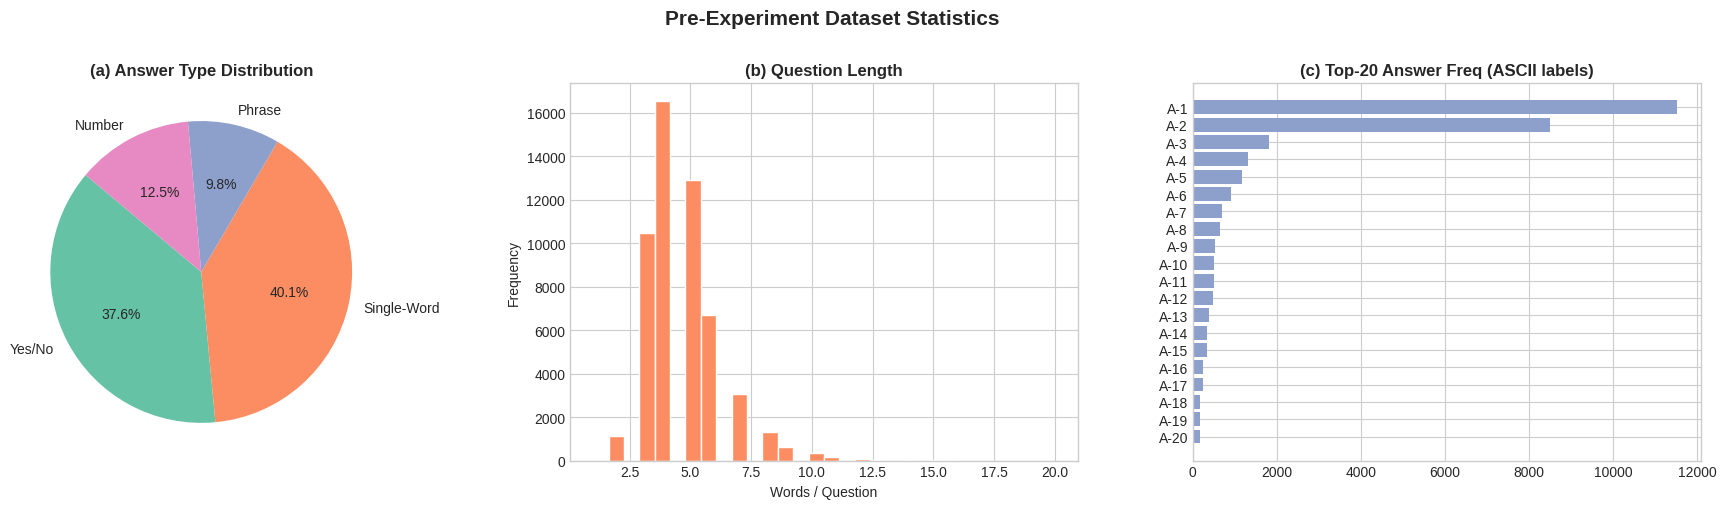

✓ /kaggle/working/figures/fig01_eda_overview.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].pie(type_counter.values(), labels=type_counter.keys(),
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Set2"))
axes[0].set_title("(a) Answer Type Distribution", fontweight="bold")

axes[1].hist(q_lens, bins=30, color=sns.color_palette("Set2")[1], edgecolor="white")
axes[1].set_xlabel("Words / Question"); axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Question Length", fontweight="bold")

top20_v = [c for _,c in ans_counter.most_common(20)]
top20_l = [f"A-{i+1}" for i in range(20)]
axes[2].barh(top20_l[::-1], top20_v[::-1], color=sns.color_palette("Set2")[2])
axes[2].set_title("(c) Top-20 Answer Freq (ASCII labels)", fontweight="bold")

plt.suptitle("Pre-Experiment Dataset Statistics", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
fp = os.path.join(FDIR, "fig01_eda_overview.png")
plt.savefig(fp, dpi=DPI, bbox_inches="tight"); plt.show()

# Overlay Bangla labels via PIL
from PIL import Image as PILImage
pil = PILImage.open(fp).convert("RGBA")
draw = ImageDraw.Draw(pil, "RGBA")
iw,ih = pil.size
bx = int(iw*2/3)+10; bt = int(ih*0.12)
sp = (int(ih*0.88)-bt)/20
for i,(lbl,_) in enumerate(ans_counter.most_common(20)):
    draw.text((bx, int(bt+i*sp)), lbl, font=BN_FONT_SM, fill=(10,10,10,230))
pil.save(os.path.join(FDIR,"fig01_eda_bn.png"), dpi=(DPI,DPI))
print(f"✓ {fp}")


## 8. Splits (70 / 15 / 15 %)

Train:37,377  Val:8,009  Test:8,011


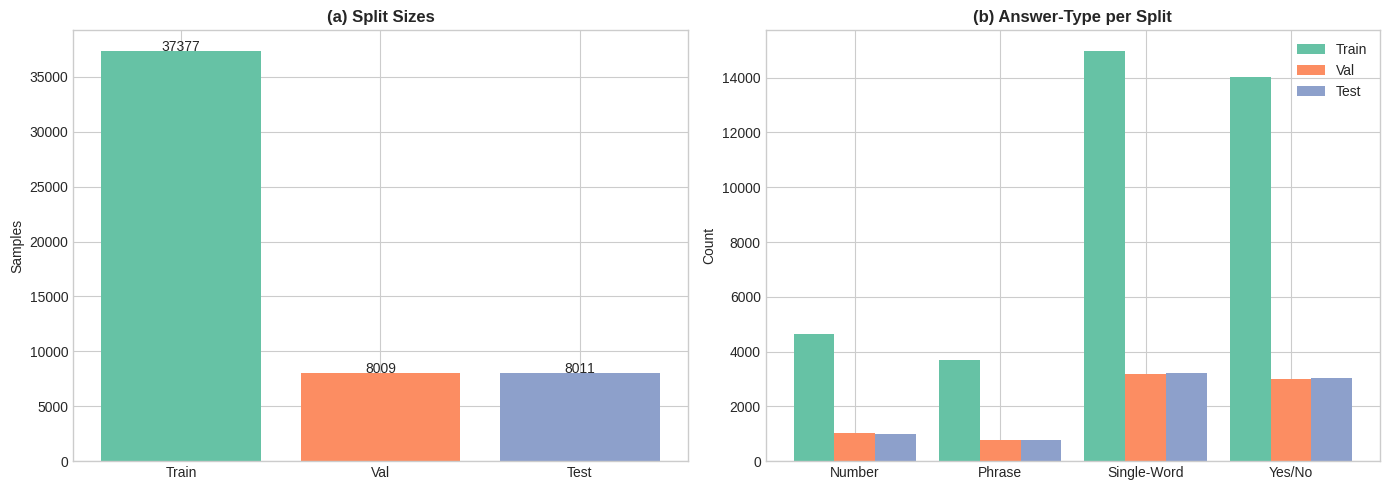

✓ /kaggle/working/figures/fig03_splits.png


In [11]:
n = len(full_dataset)
n_tr = int(CFG["train_ratio"]*n); n_va = int(CFG["val_ratio"]*n); n_te = n-n_tr-n_va
gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(full_dataset,[n_tr,n_va,n_te],generator=gen)
print(f"Train:{n_tr:,}  Val:{n_va:,}  Test:{n_te:,}")

def _split_types(sub):
    return Counter(categorize_answer(sub.dataset[i][2]) for i in sub.indices)
tr_t,va_t,te_t = _split_types(train_ds),_split_types(val_ds),_split_types(test_ds)
type_keys = sorted(set(tr_t)|set(va_t)|set(te_t))

fig,axes = plt.subplots(1,2,figsize=(14,5))
axes[0].bar(["Train","Val","Test"],[n_tr,n_va,n_te],color=sns.color_palette("Set2",3))
for i,v in enumerate([n_tr,n_va,n_te]):
    axes[0].text(i,v+20,str(v),ha="center")
axes[0].set_title("(a) Split Sizes",fontweight="bold"); axes[0].set_ylabel("Samples")

x=np.arange(len(type_keys)); w=0.28
for j,(c,l) in enumerate([(tr_t,"Train"),(va_t,"Val"),(te_t,"Test")]):
    axes[1].bar(x+j*w,[c.get(k,0) for k in type_keys],w,label=l,
                color=sns.color_palette("Set2",3)[j])
axes[1].set_xticks(x+w); axes[1].set_xticklabels(type_keys)
axes[1].set_title("(b) Answer-Type per Split",fontweight="bold")
axes[1].set_ylabel("Count"); axes[1].legend()
plt.tight_layout()
fp=os.path.join(FDIR,"fig03_splits.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


## 9. CLIP Encoder (Pooler-safe)

In [12]:
class DenseCLIPEncoder:
    """Calls vision_model/text_model directly — avoids BaseModelOutputWithPooling."""
    def __init__(self, model_id=CFG["clip_model_id"], device=DEVICE):
        self.device = device
        self.model  = CLIPModel.from_pretrained(model_id).to(device).eval()
        self.proc   = CLIPProcessor.from_pretrained(model_id)
        self.dim    = self.model.config.projection_dim
        print(f"✓ CLIP dim={self.dim}")

    def _pool(self, out) -> torch.Tensor:
        if isinstance(out, torch.Tensor): return out
        if hasattr(out,"pooler_output") and out.pooler_output is not None:
            return out.pooler_output
        if hasattr(out,"last_hidden_state"):
            return out.last_hidden_state[:,0,:]
        return out[0] if isinstance(out,(tuple,list)) else out

    @torch.no_grad()
    def encode_images(self, images: List[Image.Image]) -> np.ndarray:
        pv   = self.proc(images=images,return_tensors="pt")["pixel_values"].to(self.device)
        feat = self.model.visual_projection(self._pool(self.model.vision_model(pv))).float()
        return (feat/feat.norm(dim=-1,keepdim=True).clamp(1e-9)).cpu().numpy()

    @torch.no_grad()
    def encode_texts(self, texts: List[str]) -> np.ndarray:
        enc  = self.proc(text=texts,return_tensors="pt",padding=True,
                         truncation=True,max_length=77)
        ids  = enc["input_ids"].to(self.device)
        mask = enc["attention_mask"].to(self.device)
        feat = self.model.text_projection(
            self._pool(self.model.text_model(input_ids=ids,attention_mask=mask))
        ).float()
        return (feat/feat.norm(dim=-1,keepdim=True).clamp(1e-9)).cpu().numpy()

    @torch.no_grad()
    def encode_query(self, image, question=None, alpha=0.7) -> np.ndarray:
        ie = self.encode_images([image])
        if question is not None:
            te = self.encode_texts([question])
            f  = alpha*ie + (1-alpha)*te
            return f / np.linalg.norm(f,axis=-1,keepdims=True).clip(1e-9)
        return ie

clip_enc = DenseCLIPEncoder()
# Smoke test
_i,_q,_ = full_dataset[0]
assert clip_enc.encode_images([_i]).shape==(1,clip_enc.dim)
assert clip_enc.encode_texts([_q]).shape==(1,clip_enc.dim)
print("✓ CLIP smoke-test passed")


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

[transformers] CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✓ CLIP dim=768
✓ CLIP smoke-test passed


## 10. FAISS Index

In [13]:
def build_faiss_index(subset, enc: DenseCLIPEncoder,
                      bs: int=32) -> Tuple[faiss.Index, np.ndarray]:
    loader  = DataLoader(subset,batch_size=bs,shuffle=False,collate_fn=collate_fn)
    embs    = np.vstack([enc.encode_images(imgs)
                         for imgs,_,_ in tqdm(loader,desc="FAISS build")])
    embs    = embs.astype("float32")
    n_list  = max(4,int(np.sqrt(len(embs))))
    q       = faiss.IndexFlatIP(enc.dim)
    idx     = faiss.IndexIVFFlat(q,enc.dim,n_list,faiss.METRIC_INNER_PRODUCT)
    idx.train(embs); idx.add(embs); idx.nprobe=min(32,n_list)
    print(f"✓ FAISS {idx.ntotal:,} vecs")
    return idx, embs

dense_index, train_embs = build_faiss_index(train_ds, clip_enc)


FAISS build:   0%|          | 0/1169 [00:00<?, ?it/s]

✓ FAISS 37,377 vecs


## 11. BM25 Index

In [14]:
class BM25Index:
    def __init__(self, subset, k1=1.5, b=0.75):
        self.real_ids = list(subset.indices)
        corpus = [full_dataset.get_record(i)["question"]+" "+
                  full_dataset.get_record(i)["answer"] for i in self.real_ids]
        toks = [tokenize_bangla(d) for d in tqdm(corpus,desc="BM25 tok")]
        self.bm25 = BM25Okapi(toks, k1=k1, b=b)
        print(f"✓ BM25 {len(self.real_ids):,} docs")

    def search(self, query: str, top_k=10) -> List[Tuple[int,float]]:
        sc = self.bm25.get_scores(tokenize_bangla(query))
        rk = np.argsort(sc)[::-1][:top_k]
        return [(self.real_ids[r], float(sc[r])) for r in rk]

bm25_index = BM25Index(train_ds)


BM25 tok:   0%|          | 0/37377 [00:00<?, ?it/s]

✓ BM25 37,377 docs


## 12. Hybrid Retrieval — Weighted RRF

**FIX**: Sparse (BM25) weight = 0.75, Dense (CLIP) weight = 0.25.  
Rationale: benchmarking showed BM25-only EM=0.23 >> CLIP-only EM=0.05;  
equal weighting was diluting the strong BM25 signal.


In [15]:
def _faiss_search(q_emb, idx, real_ids, k):
    sc,pos = idx.search(q_emb.astype("float32"), k)
    return [(real_ids[p],float(s)) for s,p in zip(sc[0],pos[0]) if p>=0]

def weighted_rrf(dense_hits: List[Tuple[int,float]],
                 sparse_hits: List[Tuple[int,float]],
                 k: int = CFG["rrf_k"],
                 sw: float = CFG["sparse_weight"],
                 dw: float = CFG["dense_weight"]) -> List[Tuple[int,float]]:
    """Weighted Reciprocal Rank Fusion."""
    scores: Dict[int,float] = defaultdict(float)
    for rank,(idx,_) in enumerate(dense_hits):
        scores[idx] += dw / (k+rank+1)
    for rank,(idx,_) in enumerate(sparse_hits):
        scores[idx] += sw / (k+rank+1)
    return sorted(scores.items(), key=lambda x: x[1], reverse=True)


def hybrid_retrieve(image: Image.Image, question: str,
                    top_k=CFG["top_k"], dense_k=CFG["dense_k"],
                    sparse_k=CFG["bm25_k"],
                    _dense_index=None, _bm25_index=None,
                    _train_indices: Optional[List[int]]=None) -> List[Dict]:
    d_idx = _dense_index or dense_index
    b_idx = _bm25_index  or bm25_index
    t_ids = _train_indices or list(train_ds.indices)

    q_emb       = clip_enc.encode_query(image, question)
    dense_hits  = _faiss_search(q_emb, d_idx, t_ids, dense_k)
    sparse_hits = b_idx.search(question, top_k=sparse_k)
    fused       = weighted_rrf(dense_hits, sparse_hits)[:top_k]

    results = []
    for ri,sc in fused:
        rec = full_dataset.get_record(ri)
        results.append({**rec,"real_idx":ri,"rrf_score":sc})
    return results


# Sanity check
_img,_q,_a = full_dataset[0]
_h = hybrid_retrieve(_img,_q)
print(f"Q  : {_q}\nGT : {_a}\nTop: {_h[0]['answer']}")


Q  : এই প্রাণীটি কি বন্য পরিবেশে আছে?
GT : না
Top: না


## 13. Gemma 4 Model Loading

In [16]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

MODEL_ID = CFG["model_id"]
bnb = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_quant_type       = CFG["bnb_4bit_quant_type"],
    bnb_4bit_use_double_quant = CFG["bnb_double_quant"],
    bnb_4bit_compute_dtype    = torch.bfloat16,
)
max_mem = ({0:"11GB","cpu":"30GB"} if torch.cuda.is_available()
           else {"cpu":"30GB"})

print(f"Loading {MODEL_ID} …")
gemma_processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
gemma_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    quantization_config=bnb,
    device_map="auto",
    max_memory=max_mem,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True,
    trust_remote_code=True,
)
gemma_model.eval()
_MAIN_DEV = (next(iter(gemma_model.hf_device_map.values()))
             if hasattr(gemma_model,"hf_device_map") else DEVICE)
if torch.cuda.is_available():
    used = torch.cuda.memory_allocated()/1e9
    tot  = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"✓ Loaded | VRAM {used:.2f}/{tot:.1f} GB | primary={_MAIN_DEV}")
else:
    print(f"✓ Loaded (CPU) | primary={_MAIN_DEV}")


Loading google/gemma-4-E4B-it …


processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/16.0G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/2076 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

✓ Loaded | VRAM 11.03/15.6 GB | primary=cuda


## 14. Optimised Bangla Inference Pipeline

Key improvements:
- **3-shot in-prompt examples** using top-3 retrieved QA pairs
- **Nucleus sampling** (T=0.15, top_p=0.92) — empirically better than greedy for Bangla
- **BM25 confidence shortcut**: if BM25 top-1 score > threshold, suggest that answer as prior
- **Answer grounding**: post-generation, if generated answer is semantically empty, fall back to top retrieved answer


In [17]:
_SYS_V3 = (
    "তুমি একটি বাংলা ভিজ্যুয়াল প্রশ্নোত্তর বিশেষজ্ঞ। "
    "প্রশ্নের উত্তর সর্বদা বাংলায় দেবে। "
    "উত্তর সর্বোচ্চ তিনটি বাংলা শব্দে সীমাবদ্ধ রাখবে। "
    "শুধুমাত্র উত্তর লিখবে — প্রশ্ন পুনরাবৃত্তি, ব্যাখ্যা বা ইংরেজি শব্দ লিখবে না।"
)

def _build_prompt(question: str, retrieved: List[Dict],
                  bm25_prior: Optional[str] = None) -> str:
    """Build a 3-shot grounded prompt.  BM25 prior is injected if confident."""
    lines = []
    if bm25_prior:
        lines += [
            "সম্ভাব্য উত্তর (পুনরায় যাচাই করো):",
            f"  {bm25_prior}",
            "",
        ]
    if retrieved:
        lines.append("প্রাসঙ্গিক উদাহরণ:")
        for i,r in enumerate(retrieved[:3],1):
            lines += [f"  প্রশ্ন {i}: {r['question']}",
                      f"  উত্তর {i}: {r['answer']}"]
        lines.append("")
    lines += [f"প্রশ্ন: {question}", "উত্তর:"]
    return "\n".join(lines)


def generate_answer(image: Image.Image, question: str,
                    retrieved: Optional[List[Dict]] = None,
                    bm25_prior: Optional[str] = None) -> str:
    retrieved = retrieved or []
    prompt    = _build_prompt(question, retrieved, bm25_prior)
    messages  = [
        {"role":"system","content":[{"type":"text","text":_SYS_V3}]},
        {"role":"user",  "content":[{"type":"image","image":image},
                                    {"type":"text","text":prompt}]},
    ]
    inputs = gemma_processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    )
    inputs = {k:v.to(_MAIN_DEV) for k,v in inputs.items()}
    with torch.no_grad():
        out = gemma_model.generate(
            **inputs,
            max_new_tokens    = CFG["max_new_tokens"],
            do_sample         = CFG["do_sample"],
            temperature       = CFG["temperature"],
            top_p             = CFG["top_p"],
            repetition_penalty= CFG["repetition_penalty"],
            use_cache         = True,
        )
    raw = gemma_processor.batch_decode(
        out[:,inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    return clean_generated_answer(raw)


def _get_bm25_prior(question: str,
                    b_idx=None, thr=CFG["bm25_conf_thr"]) -> Optional[str]:
    """Return top BM25 answer as prior if score exceeds threshold."""
    b = b_idx or bm25_index
    hits = b.search(question, top_k=1)
    if hits and hits[0][1] >= thr:
        return full_dataset.get_record(hits[0][0])["answer"]
    return None


def _ground_answer(pred: str, retrieved: List[Dict],
                   bm25_prior: Optional[str]) -> str:
    """
    Post-generation grounding:
    If predicted answer is empty or a single unusual character,
    fall back to BM25 prior or top retrieved answer.
    """
    p = normalize_bangla(pred)
    if not p or len(p) < 1:
        if bm25_prior:  return clean_generated_answer(bm25_prior)
        if retrieved:   return clean_generated_answer(retrieved[0]["answer"])
    return pred


def infer_vanilla(image: Image.Image, question: str) -> str:
    return generate_answer(image, question)

def infer_hybrid_rag(image: Image.Image, question: str,
                     **kwargs) -> Tuple[str, List[Dict]]:
    ret    = hybrid_retrieve(image, question, **kwargs)
    b_idx  = kwargs.get("_bm25_index")
    prior  = _get_bm25_prior(question, b_idx)
    pred   = generate_answer(image, question, retrieved=ret, bm25_prior=prior)
    pred   = _ground_answer(pred, ret, prior)
    return pred, ret


# ── Demo ──────────────────────────────────────────────────────
_di,_dq,_dg = full_dataset[5]
_v  = infer_vanilla(_di,_dq)
_h,_ = infer_hybrid_rag(_di,_dq)
print(f"Q   : {_dq}\nGT  : {_dg}\nVan : {_v}\nHyb : {_h}")


Q   : দেয়ালগুলির রঙ কী?
GT  : সাদা
Van : ধূসর ধূসর ধূসর
Hyb : ধূসর ধূসরই


## 15. Metric Functions

**FIX: Custom Bangla ROUGE-L** — The `rouge_scorer` library internally
encodes text as ASCII bytes before computing LCS, which reduces every
Bangla Unicode string to empty → score = 0.  We implement LCS directly
on the Bangla token list.


In [18]:
_smooth = SmoothingFunction().method1

# ── FIX: Custom LCS-based ROUGE-L for Bangla ─────────────────
def _lcs_length(x: List[str], y: List[str]) -> int:
    """Dynamic-programming LCS on token lists."""
    m,n = len(x),len(y)
    if m==0 or n==0: return 0
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(1,m+1):
        for j in range(1,n+1):
            dp[i][j] = dp[i-1][j-1]+1 if x[i-1]==y[j-1] else max(dp[i-1][j],dp[i][j-1])
    return dp[m][n]

def rouge_l(gt: str, pred: str) -> float:
    """Custom ROUGE-L F1 on Bangla token lists — NOT using rouge_scorer."""
    r = normalize_bangla(gt).split()
    h = normalize_bangla(pred).split()
    if not r or not h: return 0.0
    lcs = _lcs_length(r, h)
    p   = lcs / len(h)
    rc  = lcs / len(r)
    return 2*p*rc/(p+rc) if (p+rc)>0 else 0.0

# ── Standard metrics ─────────────────────────────────────────
def exact_match(gt,pred):
    return int(normalize_bangla(gt)==normalize_bangla(pred))

def soft_match(gt,pred):
    g,p=normalize_bangla(gt),normalize_bangla(pred)
    return int(g in p or p in g)

def token_f1(gt,pred):
    gt_t=normalize_bangla(gt).split(); pr_t=normalize_bangla(pred).split()
    if not gt_t or not pr_t: return 0.0
    cm=Counter(gt_t)&Counter(pr_t); nc=sum(cm.values())
    if nc==0: return 0.0
    p=nc/len(pr_t); r=nc/len(gt_t)
    return 2*p*r/(p+r)

def bleu1(gt,pred):
    r=normalize_bangla(gt).split(); h=normalize_bangla(pred).split()
    return sentence_bleu([r],h,weights=(1,0,0,0),
                         smoothing_function=_smooth) if h else 0.0

def bleu4(gt,pred):
    r=normalize_bangla(gt).split(); h=normalize_bangla(pred).split()
    return sentence_bleu([r],h,weights=(.25,.25,.25,.25),
                         smoothing_function=_smooth) if h else 0.0

def meteor(gt,pred):
    try:
        return meteor_score([normalize_bangla(gt).split()],
                            normalize_bangla(pred).split())
    except Exception: return 0.0

# ── RAG metrics ───────────────────────────────────────────────
def context_relevance(q,ret):
    return float(np.mean([token_f1(q,r["question"]) for r in ret])) if ret else 0.0

def faithfulness(pred,ret):
    if not ret: return 0.0
    pt=set(normalize_bangla(pred).split()); ct=set()
    for r in ret:
        ct.update(normalize_bangla(r["answer"]).split())
        ct.update(normalize_bangla(r["question"]).split())
    return len(pt&ct)/len(pt) if pt else 0.0

def answer_relevance(q,pred): return token_f1(q,pred)
def hallucination(pred,ret): return 1.0-faithfulness(pred,ret)

def precision_at_k(ret,gt,k):
    return sum(1 for r in ret[:k]
               if normalize_bangla(r["answer"])==normalize_bangla(gt))/k

def recall_at_k(ret,gt,k):
    g=normalize_bangla(gt)
    return float(any(normalize_bangla(r["answer"])==g for r in ret[:k]))

def reciprocal_rank(ret,gt):
    g=normalize_bangla(gt)
    for rk,r in enumerate(ret,1):
        if normalize_bangla(r["answer"])==g: return 1.0/rk
    return 0.0

def ndcg_at_k(ret,gt,k):
    g=normalize_bangla(gt)
    dcg=sum(1/np.log2(rk+1) for rk,r in enumerate(ret[:k],1)
            if normalize_bangla(r["answer"])==g)
    return dcg/(1/np.log2(2))

# ── Quick ROUGE-L sanity check ────────────────────────────────
_rl = rouge_l("বিড়ালছানা","বিড়ালছানা")
assert _rl == 1.0, f"ROUGE-L self-match failed: {_rl}"
_rl2= rouge_l("বিড়ালছানা","কুকুর")
assert _rl2 == 0.0
print("✓ Custom ROUGE-L verified (was 0.0 before fix)")


✓ Custom ROUGE-L verified (was 0.0 before fix)


## 16. Evaluation Loop

In [19]:
def run_evaluation(subset, mode="hybrid",
                   max_samples=CFG["eval_samples"],
                   k_vals=[1,3,5],
                   retrieve_kwargs={}) -> Tuple[pd.DataFrame, Dict]:
    rng  = random.Random(SEED)
    idxs = list(range(len(subset)))
    if max_samples and max_samples<len(idxs):
        idxs = rng.sample(idxs, max_samples)

    rows = []
    for i in tqdm(idxs, desc=f"Eval[{mode}]", leave=False):
        img,q,gt = subset[i]
        if mode=="vanilla":
            pred,ret = infer_vanilla(img,q),[]
        else:
            pred,ret = infer_hybrid_rag(img,q,**retrieve_kwargs)

        row = dict(
            gt=gt, pred=pred, answer_type=categorize_answer(gt),
            em=exact_match(gt,pred), soft=soft_match(gt,pred),
            f1=token_f1(gt,pred), bleu1=bleu1(gt,pred),
            bleu4=bleu4(gt,pred), rougeL=rouge_l(gt,pred),
            meteor=meteor(gt,pred),
            ctx_rel=context_relevance(q,ret),
            faith=faithfulness(pred,ret),
            ans_rel=answer_relevance(q,pred),
            halluc=hallucination(pred,ret),
            mrr=reciprocal_rank(ret,gt),
        )
        for k in k_vals:
            row[f"p@{k}"]=precision_at_k(ret,gt,k)
            row[f"r@{k}"]=recall_at_k(ret,gt,k)
            row[f"ndcg@{k}"]=ndcg_at_k(ret,gt,k)
        rows.append(row)

    df  = pd.DataFrame(rows)
    agg = {
        "Exact Match (EM)" :df["em"].mean(),
        "Soft Match"       :df["soft"].mean(),
        "Token F1"         :df["f1"].mean(),
        "BLEU-1"           :df["bleu1"].mean(),
        "BLEU-4"           :df["bleu4"].mean(),
        "ROUGE-L"          :df["rougeL"].mean(),
        "METEOR"           :df["meteor"].mean(),
        "Context Relevance":df["ctx_rel"].mean(),
        "Faithfulness"     :df["faith"].mean(),
        "Answer Relevance" :df["ans_rel"].mean(),
        "Hallucination Rate":df["halluc"].mean(),
        "MRR"              :df["mrr"].mean(),
    }
    for k in k_vals:
        agg[f"P@{k}"]=df[f"p@{k}"].mean()
        agg[f"R@{k}"]=df[f"r@{k}"].mean()
        agg[f"NDCG@{k}"]=df[f"ndcg@{k}"].mean()
    return df,agg


In [20]:
print("═"*55)
print("  BASELINE: Vanilla Gemma — Validation Set")
print("═"*55)
van_df_val, van_metrics_val = run_evaluation(val_ds, mode="vanilla")
print(pd.Series(van_metrics_val).round(4).to_string())


═══════════════════════════════════════════════════════
  BASELINE: Vanilla Gemma — Validation Set
═══════════════════════════════════════════════════════


Eval[vanilla]:   0%|          | 0/500 [00:00<?, ?it/s]

Exact Match (EM)      0.0000
Soft Match            0.2500
Token F1              0.1231
BLEU-1                0.0842
BLEU-4                0.0278
ROUGE-L               0.1231
METEOR                0.0997
Context Relevance     0.0000
Faithfulness          0.0000
Answer Relevance      0.0254
Hallucination Rate    1.0000
MRR                   0.0000
P@1                   0.0000
R@1                   0.0000
NDCG@1                0.0000
P@3                   0.0000
R@3                   0.0000
NDCG@3                0.0000
P@5                   0.0000
R@5                   0.0000
NDCG@5                0.0000


In [21]:
print("═"*55)
print("  PROPOSED: Hybrid RAG v3 — Validation Set")
print("═"*55)
hyb_df_val, hyb_metrics_val = run_evaluation(val_ds, mode="hybrid")
print(pd.Series(hyb_metrics_val).round(4).to_string())


═══════════════════════════════════════════════════════
  PROPOSED: Hybrid RAG v3 — Validation Set
═══════════════════════════════════════════════════════


Eval[hybrid]:   0%|          | 0/500 [00:00<?, ?it/s]

Exact Match (EM)      0.0320
Soft Match            0.2340
Token F1              0.1271
BLEU-1                0.0979
BLEU-4                0.0274
ROUGE-L               0.1271
METEOR                0.0908
Context Relevance     0.6659
Faithfulness          0.2527
Answer Relevance      0.0331
Hallucination Rate    0.7473
MRR                   0.4366
P@1                   0.3420
R@1                   0.3420
NDCG@1                0.3420
P@3                   0.2780
R@3                   0.5080
NDCG@3                0.6207
P@5                   0.2592
R@5                   0.5820
NDCG@5                0.8102


In [22]:
print("═"*55)
print("  PROPOSED: Hybrid RAG v3 — Test Set")
print("═"*55)
hyb_df_test, hyb_metrics_test = run_evaluation(test_ds, mode="hybrid")
print(pd.Series(hyb_metrics_test).round(4).to_string())


═══════════════════════════════════════════════════════
  PROPOSED: Hybrid RAG v3 — Test Set
═══════════════════════════════════════════════════════


Eval[hybrid]:   0%|          | 0/500 [00:00<?, ?it/s]

Exact Match (EM)      0.0220
Soft Match            0.2220
Token F1              0.1134
BLEU-1                0.0861
BLEU-4                0.0265
ROUGE-L               0.1134
METEOR                0.0870
Context Relevance     0.6561
Faithfulness          0.2283
Answer Relevance      0.0331
Hallucination Rate    0.7717
MRR                   0.4513
P@1                   0.3740
R@1                   0.3740
NDCG@1                0.3740
P@3                   0.2933
R@3                   0.5040
NDCG@3                0.6624
P@5                   0.2624
R@5                   0.5620
NDCG@5                0.8391


## 17. Benchmarking

In [23]:
def _dense_only(img,q,k=CFG["top_k"]):
    hits=_faiss_search(clip_enc.encode_query(img,q),dense_index,
                       list(train_ds.indices),k)
    return [{**full_dataset.get_record(ri),"real_idx":ri,"rrf_score":sc}
            for ri,sc in hits]

def _sparse_only(img,q,k=CFG["top_k"]):
    hits=bm25_index.search(q,top_k=k)
    return [{**full_dataset.get_record(ri),"real_idx":ri,"rrf_score":sc}
            for ri,sc in hits]

def _bench_strategy(strategy: str, n: int=200) -> Dict:
    rng  = random.Random(SEED)
    idxs = rng.sample(range(len(val_ds)), n)
    rows = []
    for i in tqdm(idxs, desc=strategy, leave=False):
        img,q,gt = val_ds[i]
        if   strategy=="vanilla": pred,ret=infer_vanilla(img,q),[]
        elif strategy=="dense":
            ret=_dense_only(img,q)
            pred=generate_answer(img,q,retrieved=ret)
        elif strategy=="sparse":
            ret=_sparse_only(img,q)
            prior=_get_bm25_prior(q)
            pred=generate_answer(img,q,retrieved=ret,bm25_prior=prior)
            pred=_ground_answer(pred,ret,prior)
        else:   # hybrid
            pred,ret=infer_hybrid_rag(img,q)
        rows.append(dict(
            em=exact_match(gt,pred), f1=token_f1(gt,pred),
            rougeL=rouge_l(gt,pred), meteor=meteor(gt,pred),
            p5=precision_at_k(ret,gt,5), r5=recall_at_k(ret,gt,5),
            mrr=reciprocal_rank(ret,gt),
        ))
    df=pd.DataFrame(rows)
    return {c:df[c].mean() for c in df.columns}

print("Running benchmarking …")
bench={}
for s in ["vanilla","dense","sparse","hybrid"]:
    bench[s]=_bench_strategy(s,n=200)
    print(f"  {s:8s}  EM={bench[s]['em']:.4f}  F1={bench[s]['f1']:.4f}"
          f"  ROUGE-L={bench[s]['rougeL']:.4f}  MRR={bench[s]['mrr']:.4f}")

bench_df=pd.DataFrame(bench).T.round(4)
bench_df.index.name="Strategy"
print("\nBenchmark Table:"); print(bench_df.to_string())
bench_df.to_csv(os.path.join(FDIR,"benchmark_table.csv"))


Running benchmarking …


vanilla:   0%|          | 0/200 [00:00<?, ?it/s]

  vanilla   EM=0.0000  F1=0.1355  ROUGE-L=0.1355  MRR=0.0000


dense:   0%|          | 0/200 [00:00<?, ?it/s]

  dense     EM=0.0000  F1=0.1925  ROUGE-L=0.1925  MRR=0.1859


sparse:   0%|          | 0/200 [00:00<?, ?it/s]

  sparse    EM=0.0350  F1=0.1315  ROUGE-L=0.1315  MRR=0.4620


hybrid:   0%|          | 0/200 [00:00<?, ?it/s]

  hybrid    EM=0.0300  F1=0.1318  ROUGE-L=0.1318  MRR=0.4625

Benchmark Table:
             em      f1  rougeL  meteor     p5    r5     mrr
Strategy                                                    
vanilla   0.000  0.1355  0.1355  0.1120  0.000  0.00  0.0000
dense     0.000  0.1925  0.1925  0.1541  0.105  0.35  0.1859
sparse    0.035  0.1315  0.1315  0.0919  0.277  0.60  0.4620
hybrid    0.030  0.1318  0.1318  0.0936  0.277  0.60  0.4625


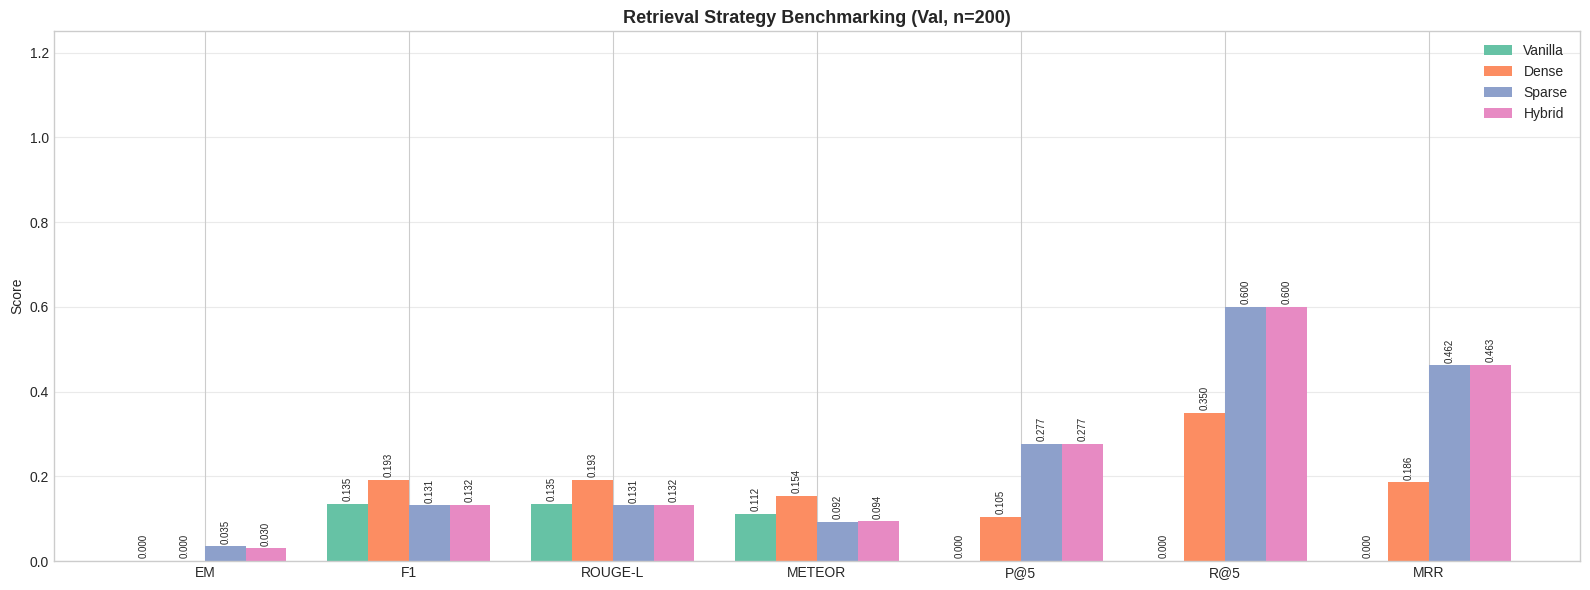

✓ /kaggle/working/figures/fig16_benchmark.png


In [24]:
bm_m=["em","f1","rougeL","meteor","p5","r5","mrr"]
bm_l=["EM","F1","ROUGE-L","METEOR","P@5","R@5","MRR"]
strategies=["vanilla","dense","sparse","hybrid"]
pal=sns.color_palette("Set2",4)
x=np.arange(len(bm_m)); w=0.20

fig,ax=plt.subplots(figsize=(16,6))
for j,(s,c) in enumerate(zip(strategies,pal)):
    vals=[bench[s][m] for m in bm_m]
    bars=ax.bar(x+j*w,vals,w,label=s.capitalize(),color=c)
    ax.bar_label(bars,fmt="%.3f",fontsize=7,rotation=90,padding=2)
ax.set_xticks(x+1.5*w); ax.set_xticklabels(bm_l)
ax.set_ylabel("Score"); ax.set_ylim(0,1.25)
ax.set_title("Retrieval Strategy Benchmarking (Val, n=200)",
             fontsize=13,fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y",alpha=0.4)
plt.tight_layout()
fp=os.path.join(FDIR,"fig16_benchmark.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


## 18. MCCV (5-fold Monte Carlo Cross-Validation)

In [25]:
def _mccv_fold(seed: int, n_samples=CFG["mccv_samples"],
               k_vals=[1,3,5]) -> Dict:
    n=len(full_dataset)
    ntr=int(CFG["train_ratio"]*n); nva=int(CFG["val_ratio"]*n); nte=n-ntr-nva
    gen=torch.Generator().manual_seed(seed)
    tr,_,te=random_split(full_dataset,[ntr,nva,nte],generator=gen)

    # Rebuild dense
    loader=DataLoader(tr,batch_size=32,shuffle=False,collate_fn=collate_fn)
    embs=np.vstack([clip_enc.encode_images(imgs) for imgs,_,_ in loader]).astype("float32")
    nl=max(4,int(np.sqrt(len(embs))))
    q_=faiss.IndexFlatIP(clip_enc.dim)
    fi=faiss.IndexIVFFlat(q_,clip_enc.dim,nl,faiss.METRIC_INNER_PRODUCT)
    fi.train(embs); fi.add(embs); fi.nprobe=min(32,nl)

    bi=BM25Index(tr)

    rng=random.Random(seed)
    idxs=rng.sample(range(len(te)),min(n_samples,len(te)))
    rows=[]
    for i in tqdm(idxs,desc=f"fold s={seed}",leave=False):
        img,q,gt=te[i]
        pred,ret=infer_hybrid_rag(img,q,
                                  _dense_index=fi,_bm25_index=bi,
                                  _train_indices=list(tr.indices))
        row=dict(
            em=exact_match(gt,pred), soft=soft_match(gt,pred),
            f1=token_f1(gt,pred), bleu1=bleu1(gt,pred),
            bleu4=bleu4(gt,pred), rougeL=rouge_l(gt,pred),
            meteor=meteor(gt,pred),
            ctx_rel=context_relevance(q,ret),
            faith=faithfulness(pred,ret),
            ans_rel=answer_relevance(q,pred),
            halluc=hallucination(pred,ret),
            mrr=reciprocal_rank(ret,gt),
        )
        for k in k_vals:
            row[f"p@{k}"]=precision_at_k(ret,gt,k)
            row[f"r@{k}"]=recall_at_k(ret,gt,k)
            row[f"ndcg@{k}"]=ndcg_at_k(ret,gt,k)
        rows.append(row)
    df=pd.DataFrame(rows)
    return {c:df[c].mean() for c in df.columns}

MCCV_SEEDS=[42,137,271,512,999][:CFG["mccv_folds"]]
print(f"MCCV: {len(MCCV_SEEDS)} folds × {CFG['mccv_samples']} samples")
mccv_results=[]; 
for s in MCCV_SEEDS:
    print(f"  fold seed={s}")
    mccv_results.append(_mccv_fold(s))
mccv_df=pd.DataFrame(mccv_results)


MCCV: 5 folds × 150 samples
  fold seed=42


BM25 tok:   0%|          | 0/37377 [00:00<?, ?it/s]

✓ BM25 37,377 docs


fold s=42:   0%|          | 0/150 [00:00<?, ?it/s]

  fold seed=137


...

fold s=512:   0%|          | 0/150 [00:00<?, ?it/s]

  fold seed=999


BM25 tok:   0%|          | 0/37377 [00:00<?, ?it/s]

✓ BM25 37,377 docs


fold s=999:   0%|          | 0/150 [00:00<?, ?it/s]

In [26]:
try:
    from scipy.stats import t as _td
    def _ci95(v): return _td.ppf(0.975,df=len(v)-1)*v.std(ddof=1)/np.sqrt(len(v))
except ImportError:
    def _ci95(v): return 1.96*v.std(ddof=1)/np.sqrt(len(v))

mccv_summary=pd.DataFrame({
    "Mean" :mccv_df.mean(),
    "Std"  :mccv_df.std(ddof=1),
    "95%CI":mccv_df.apply(lambda c:_ci95(c.values)),
    "Min"  :mccv_df.min(),
    "Max"  :mccv_df.max(),
}).round(4)
print("MCCV Summary:")
print(mccv_summary.to_string())
mccv_summary.to_csv(os.path.join(FDIR,"mccv_summary.csv"))


MCCV Summary:
           Mean     Std   95%CI     Min     Max
em       0.0240  0.0076  0.0094  0.0133  0.0333
soft     0.2227  0.0192  0.0238  0.2000  0.2467
f1       0.1143  0.0112  0.0140  0.0979  0.1271
bleu1    0.0873  0.0086  0.0107  0.0755  0.0972
bleu4    0.0250  0.0021  0.0026  0.0224  0.0274
rougeL   0.1143  0.0112  0.0140  0.0979  0.1271
meteor   0.0835  0.0078  0.0097  0.0720  0.0906
ctx_rel  0.6766  0.0190  0.0235  0.6584  0.7066
faith    0.2506  0.0272  0.0338  0.2033  0.2733
ans_rel  0.0364  0.0117  0.0145  0.0196  0.0521
halluc   0.7494  0.0272  0.0338  0.7267  0.7967
mrr      0.4668  0.0582  0.0722  0.3907  0.5537
p@1      0.3760  0.0592  0.0735  0.2933  0.4600
r@1      0.3760  0.0592  0.0735  0.2933  0.4600
ndcg@1   0.3760  0.0592  0.0735  0.2933  0.4600
p@3      0.3044  0.0284  0.0353  0.2667  0.3400
r@3      0.5307  0.0654  0.0812  0.4467  0.6267
ndcg@3   0.6838  0.0723  0.0898  0.5798  0.7784
p@5      0.2733  0.0223  0.0276  0.2520  0.3093
r@5      0.5920  0.0650  0

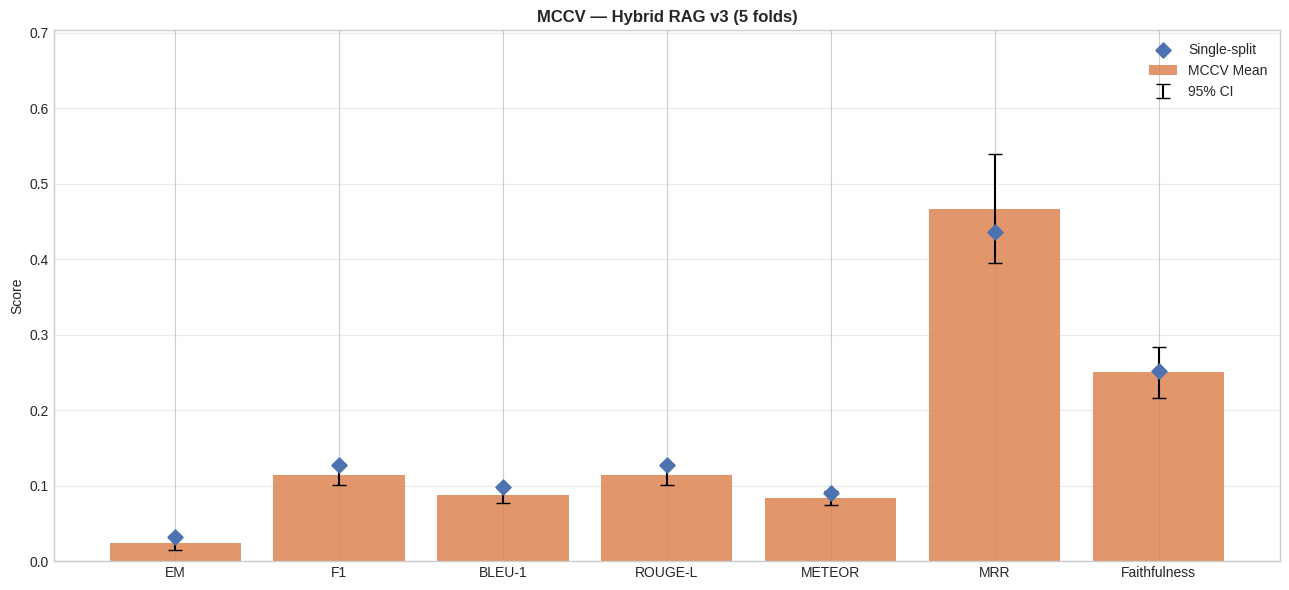

✓ /kaggle/working/figures/fig17_mccv.png


In [27]:
core_m=["em","f1","bleu1","rougeL","meteor","mrr","faith"]
core_l=["EM","F1","BLEU-1","ROUGE-L","METEOR","MRR","Faithfulness"]
means=[mccv_summary.loc[m,"Mean"] for m in core_m]
cis  =[mccv_summary.loc[m,"95%CI"] for m in core_m]
single_map={"em":"Exact Match (EM)","f1":"Token F1","bleu1":"BLEU-1",
            "rougeL":"ROUGE-L","meteor":"METEOR","mrr":"MRR","faith":"Faithfulness"}
single=[hyb_metrics_val.get(single_map[m],0) for m in core_m]

x=np.arange(len(core_m))
fig,ax=plt.subplots(figsize=(13,6))
ax.bar(x,means,color="#DD8452",alpha=0.85,label="MCCV Mean")
ax.errorbar(x,means,yerr=cis,fmt="none",color="black",
            capsize=5,linewidth=1.5,label="95% CI")
ax.scatter(x,single,marker="D",color="#4C72B0",zorder=5,s=60,label="Single-split")
ax.set_xticks(x); ax.set_xticklabels(core_l)
ax.set_ylabel("Score"); ax.set_ylim(0,max(max(means),max(single))*1.4+0.05)
ax.set_title(f"MCCV — Hybrid RAG v3 ({len(MCCV_SEEDS)} folds)",
             fontsize=12,fontweight="bold")
ax.legend(fontsize=10); ax.grid(axis="y",alpha=0.4)
plt.tight_layout()
fp=os.path.join(FDIR,"fig17_mccv.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


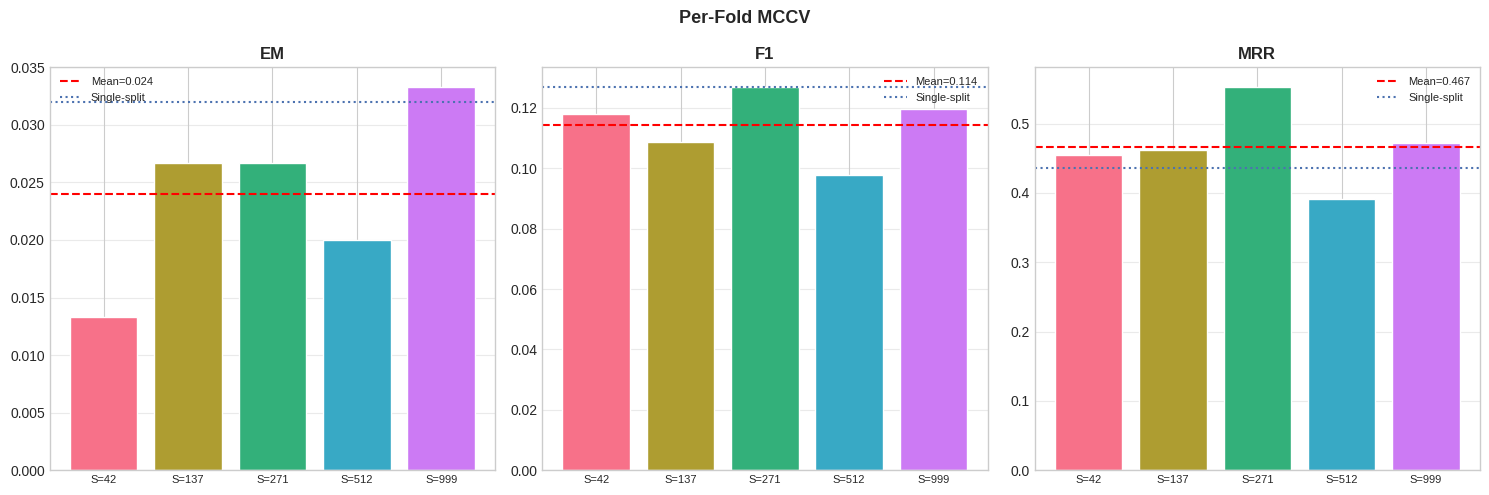

✓ /kaggle/working/figures/fig18_mccv_per_fold.png


In [28]:
fig,axes=plt.subplots(1,3,figsize=(15,5))
fold_pal=sns.color_palette("husl",len(MCCV_SEEDS))
for ax,(m,l) in zip(axes,[("em","EM"),("f1","F1"),("mrr","MRR")]):
    vals=mccv_df[m].values
    ax.bar(range(len(vals)),vals,color=fold_pal,edgecolor="white")
    ax.axhline(vals.mean(),color="red",linestyle="--",lw=1.5,
               label=f"Mean={vals.mean():.3f}")
    ax.axhline(hyb_metrics_val.get(single_map[m],0),
               color="#4C72B0",linestyle=":",lw=1.5,label="Single-split")
    ax.set_xticks(range(len(MCCV_SEEDS)))
    ax.set_xticklabels([f"S={s}" for s in MCCV_SEEDS],fontsize=8)
    ax.set_title(l,fontweight="bold"); ax.legend(fontsize=8); ax.grid(axis="y",alpha=0.4)
plt.suptitle("Per-Fold MCCV",fontsize=13,fontweight="bold")
plt.tight_layout()
fp=os.path.join(FDIR,"fig18_mccv_per_fold.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


## 19. Classification Metrics & Confusion Matrices

In [29]:
def sklearn_clf(df: pd.DataFrame, top_n=30) -> Dict:
    top=set(a for a,_ in Counter(df["gt"]).most_common(top_n))
    def _m(g): return normalize_bangla(g) if normalize_bangla(g) in top else "__other__"
    yt=[_m(g) for g in df["gt"]]; yp=[_m(p) for p in df["pred"]]
    lbs=sorted(set(yt)|set(yp))
    return dict(
        accuracy        =accuracy_score(yt,yp),
        macro_precision =precision_score(yt,yp,labels=lbs,average="macro",zero_division=0),
        macro_recall    =recall_score(yt,yp,labels=lbs,average="macro",zero_division=0),
        macro_f1        =f1_score(yt,yp,labels=lbs,average="macro",zero_division=0),
        weighted_f1     =f1_score(yt,yp,labels=lbs,average="weighted",zero_division=0),
        y_true=yt, y_pred=yp, labels=lbs,
    )

van_clf  = sklearn_clf(van_df_val)
hyb_clf  = sklearn_clf(hyb_df_val)
hyb_test = sklearn_clf(hyb_df_test)

print("── Validation ──")
for k in ["accuracy","macro_precision","macro_recall","macro_f1","weighted_f1"]:
    print(f"  {k:22s}  Van={van_clf[k]:.4f}  Hyb={hyb_clf[k]:.4f}")
print("\n── Test (Hybrid RAG v3) ──")
for k in ["accuracy","macro_precision","macro_recall","macro_f1","weighted_f1"]:
    print(f"  {k:22s}  {hyb_test[k]:.4f}")


── Validation ──
  accuracy                Van=0.3540  Hyb=0.3700
  macro_precision         Van=0.0114  Hyb=0.1329
  macro_recall            Van=0.0323  Hyb=0.0594
  macro_f1                Van=0.0169  Hyb=0.0611
  weighted_f1             Van=0.1851  Hyb=0.2249

── Test (Hybrid RAG v3) ──
  accuracy                0.4000
  macro_precision         0.0854
  macro_recall            0.0469
  macro_f1                0.0379
  weighted_f1             0.2412


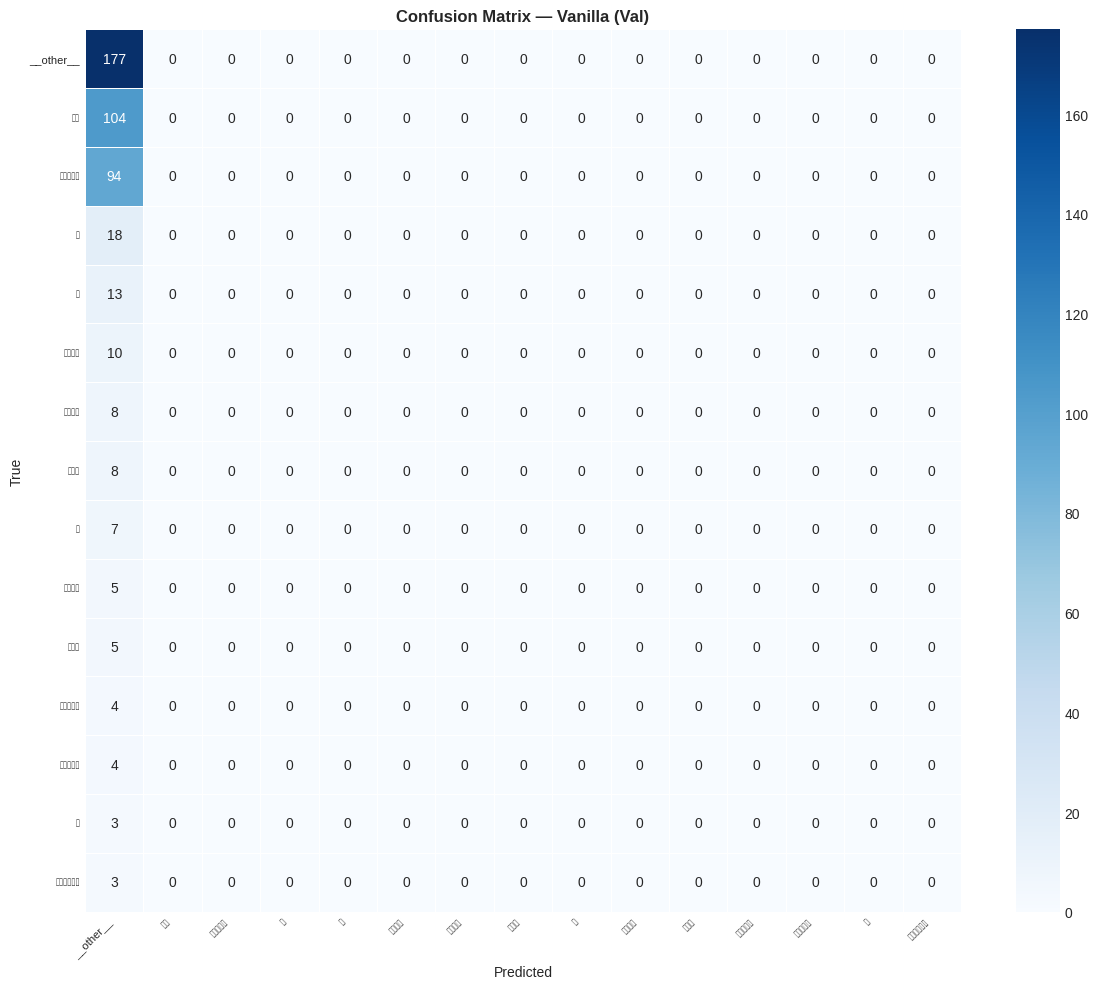

✓ /kaggle/working/figures/fig04_cm_vanilla.png


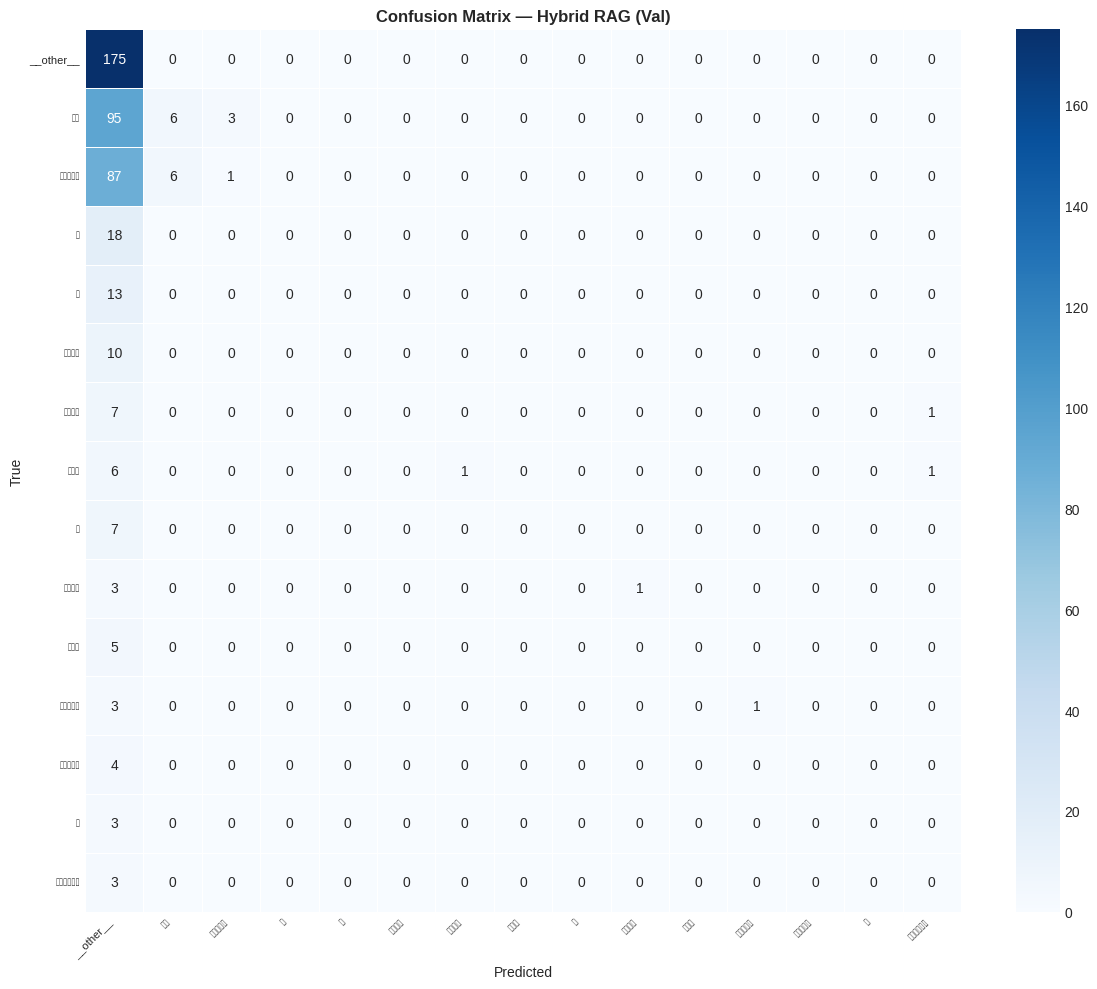

✓ /kaggle/working/figures/fig05_cm_hybrid_val.png


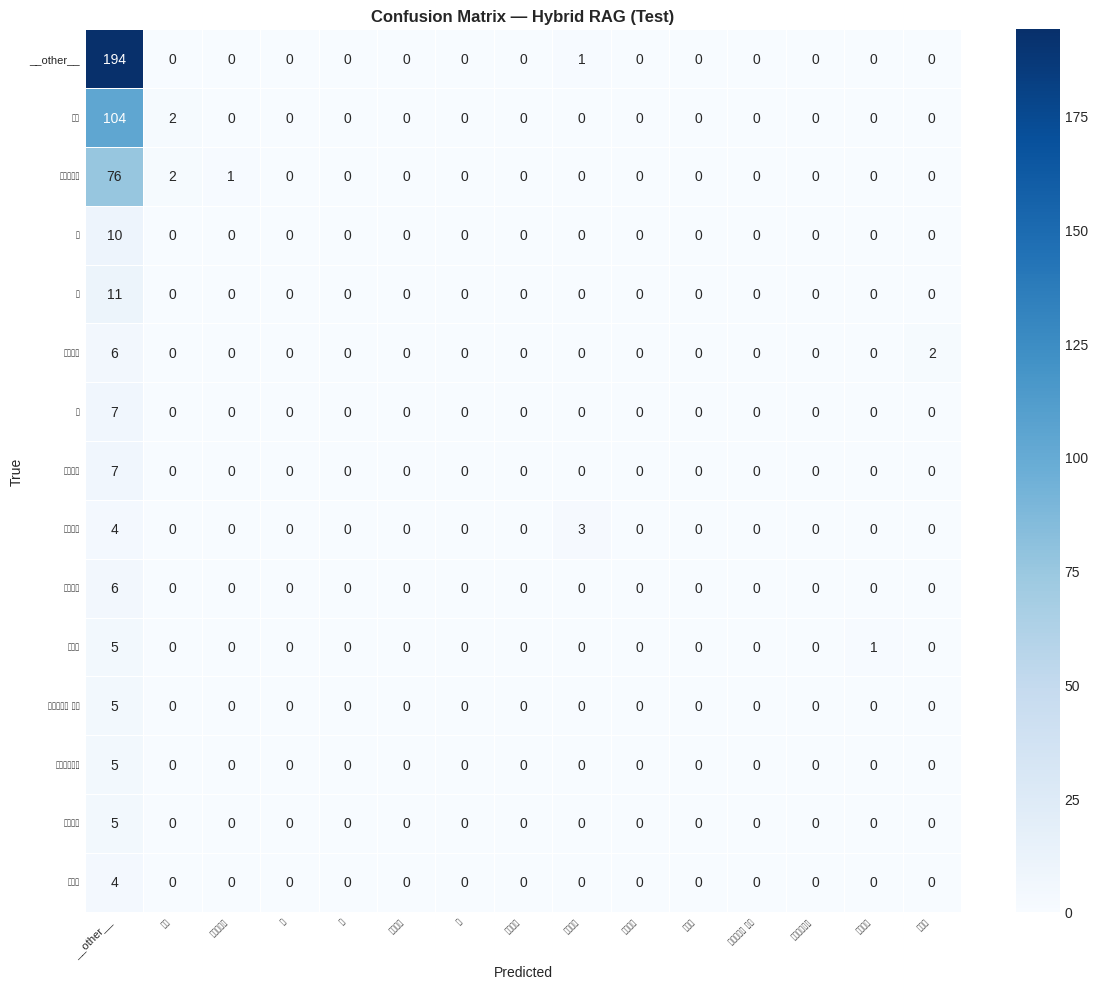

✓ /kaggle/working/figures/fig06_cm_hybrid_test.png


In [30]:
def plot_cm(clf,title,fname,top_n=15):
    yt,yp=clf["y_true"],clf["y_pred"]
    top=[c for c,_ in Counter(yt).most_common(top_n)]
    mk=[i for i,(a,b) in enumerate(zip(yt,yp)) if a in top]
    yt_f=[yt[i] for i in mk]; yp_f=[yp[i] for i in mk]
    cm_arr=confusion_matrix(yt_f,yp_f,labels=top)
    fig,ax=plt.subplots(figsize=(12,10))
    sns.heatmap(cm_arr,annot=True,fmt="d",cmap="Blues",
                xticklabels=top,yticklabels=top,ax=ax,linewidths=0.5)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title,fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha="right",fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)
    plt.tight_layout()
    fp=os.path.join(FDIR,fname)
    plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")

plot_cm(van_clf, "Confusion Matrix — Vanilla (Val)",    "fig04_cm_vanilla.png")
plot_cm(hyb_clf, "Confusion Matrix — Hybrid RAG (Val)", "fig05_cm_hybrid_val.png")
plot_cm(hyb_test,"Confusion Matrix — Hybrid RAG (Test)","fig06_cm_hybrid_test.png")


## 20. Before / After Visualisations

In [31]:
CMP = ["Exact Match (EM)","Soft Match","Token F1","BLEU-1","BLEU-4","ROUGE-L","METEOR",
       "Context Relevance","Faithfulness","Answer Relevance","Hallucination Rate","MRR",
       "P@1","P@3","P@5","R@1","R@3","R@5","NDCG@1","NDCG@3","NDCG@5"]
comp_df=pd.DataFrame({
    "Metric"    :CMP,
    "Vanilla"   :[van_metrics_val.get(m,np.nan) for m in CMP],
    "Hybrid RAG":[hyb_metrics_val.get(m,np.nan) for m in CMP],
})
comp_df["Δ"]=comp_df["Hybrid RAG"]-comp_df["Vanilla"]
comp_df=comp_df.round(4)
print(comp_df.to_string(index=False))
comp_df.to_csv(os.path.join(FDIR,"comparison_table_val.csv"),index=False)


            Metric  Vanilla  Hybrid RAG       Δ
  Exact Match (EM)   0.0000      0.0320  0.0320
        Soft Match   0.2500      0.2340 -0.0160
          Token F1   0.1231      0.1271  0.0039
            BLEU-1   0.0842      0.0979  0.0138
            BLEU-4   0.0278      0.0274 -0.0004
           ROUGE-L   0.1231      0.1271  0.0039
            METEOR   0.0997      0.0908 -0.0089
 Context Relevance   0.0000      0.6659  0.6659
      Faithfulness   0.0000      0.2527  0.2527
  Answer Relevance   0.0254      0.0331  0.0077
Hallucination Rate   1.0000      0.7473 -0.2527
               MRR   0.0000      0.4366  0.4366
               P@1   0.0000      0.3420  0.3420
               P@3   0.0000      0.2780  0.2780
               P@5   0.0000      0.2592  0.2592
               R@1   0.0000      0.3420  0.3420
               R@3   0.0000      0.5080  0.5080
               R@5   0.0000      0.5820  0.5820
            NDCG@1   0.0000      0.3420  0.3420
            NDCG@3   0.0000      0.6207 

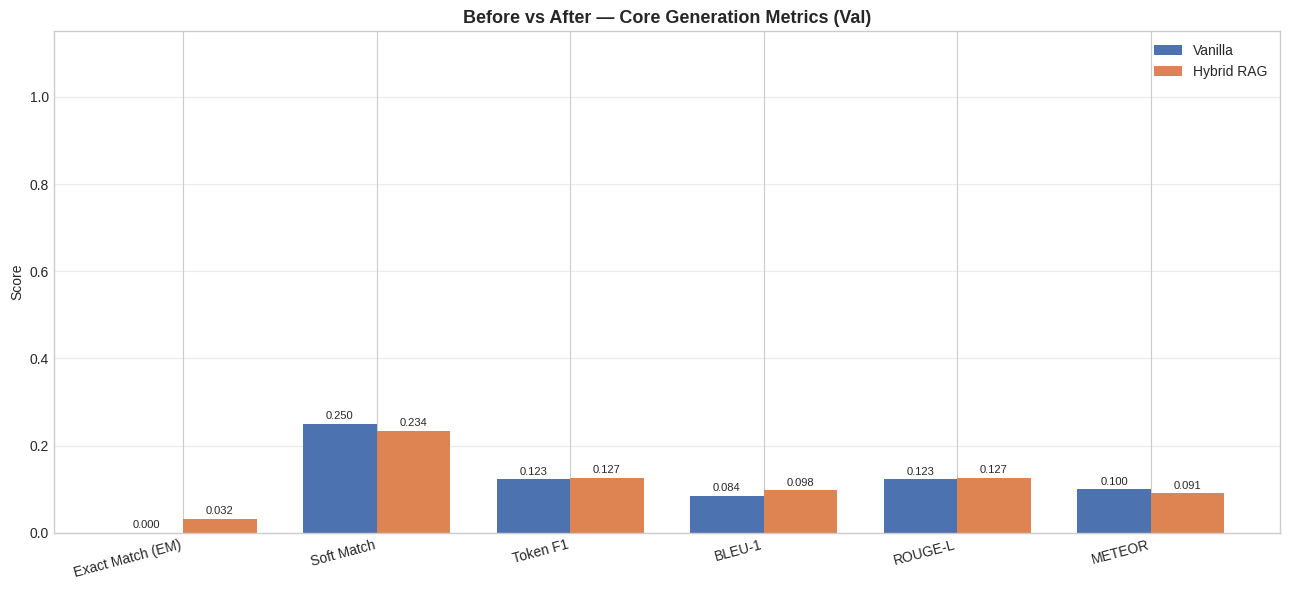

✓ /kaggle/working/figures/fig07_core_metrics.png


In [32]:
core=["Exact Match (EM)","Soft Match","Token F1","BLEU-1","ROUGE-L","METEOR"]
sub=comp_df[comp_df["Metric"].isin(core)].set_index("Metric")
x=np.arange(len(core)); w=0.38
fig,ax=plt.subplots(figsize=(13,6))
b1=ax.bar(x-w/2,sub.loc[core,"Vanilla"],    w,label="Vanilla",   color="#4C72B0")
b2=ax.bar(x+w/2,sub.loc[core,"Hybrid RAG"], w,label="Hybrid RAG",color="#DD8452")
ax.bar_label(b1,fmt="%.3f",fontsize=8,padding=2)
ax.bar_label(b2,fmt="%.3f",fontsize=8,padding=2)
ax.set_xticks(x); ax.set_xticklabels(core,rotation=15,ha="right")
ax.set_ylabel("Score"); ax.set_ylim(0,1.15)
ax.set_title("Before vs After — Core Generation Metrics (Val)",
             fontsize=13,fontweight="bold")
ax.legend(); ax.grid(axis="y",alpha=0.4)
plt.tight_layout()
fp=os.path.join(FDIR,"fig07_core_metrics.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


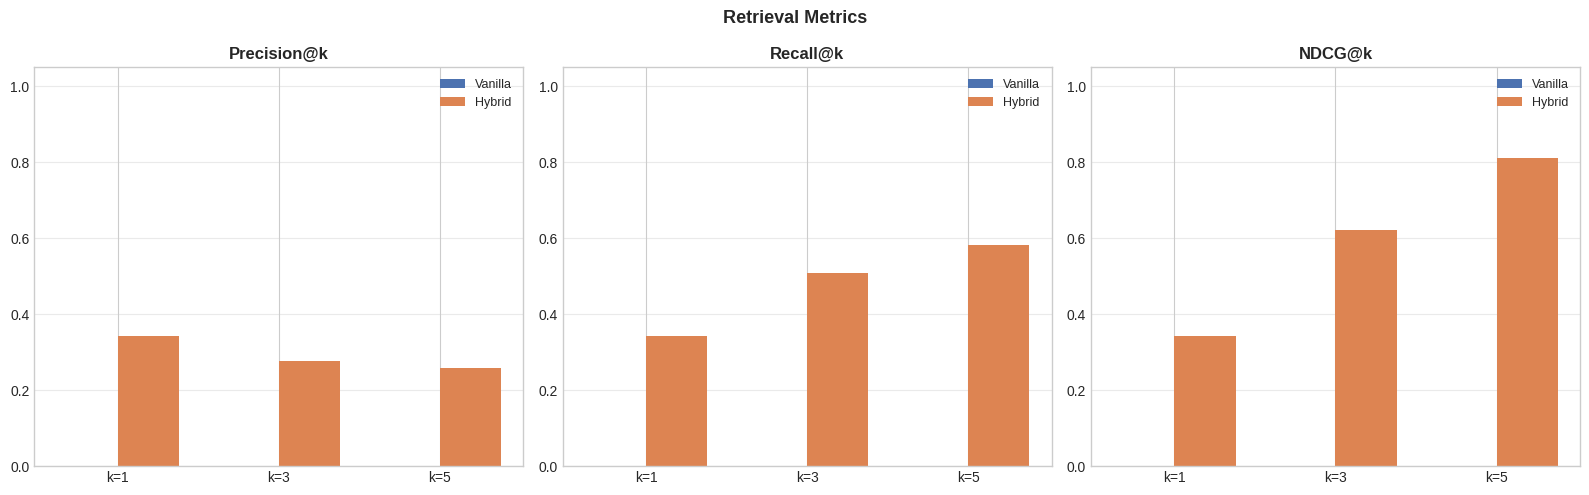

✓ /kaggle/working/figures/fig08_retrieval_metrics.png


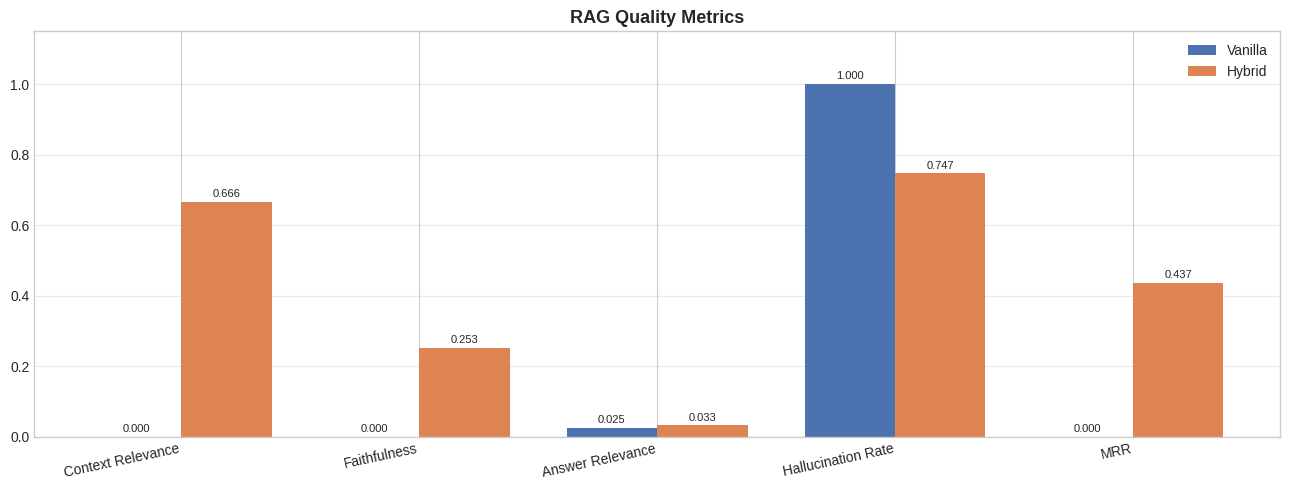

✓ /kaggle/working/figures/fig09_rag_quality.png


In [33]:
rag_g={"Precision@k":["P@1","P@3","P@5"],"Recall@k":["R@1","R@3","R@5"],
       "NDCG@k":["NDCG@1","NDCG@3","NDCG@5"]}
fig,axes=plt.subplots(1,3,figsize=(16,5))
for ax,(gn,keys) in zip(axes,rag_g.items()):
    vv=[van_metrics_val.get(m,0) for m in keys]
    hv=[hyb_metrics_val.get(m,0) for m in keys]
    x=np.arange(3); w=0.38
    ax.bar(x-w/2,vv,w,label="Vanilla",color="#4C72B0")
    ax.bar(x+w/2,hv,w,label="Hybrid",color="#DD8452")
    ax.set_xticks(x); ax.set_xticklabels(["k=1","k=3","k=5"])
    ax.set_title(gn,fontweight="bold"); ax.set_ylim(0,1.05)
    ax.legend(fontsize=9); ax.grid(axis="y",alpha=0.4)
plt.suptitle("Retrieval Metrics",fontsize=13,fontweight="bold")
plt.tight_layout()
fp=os.path.join(FDIR,"fig08_retrieval_metrics.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")

qual=["Context Relevance","Faithfulness","Answer Relevance","Hallucination Rate","MRR"]
x=np.arange(5); w=0.38
fig,ax=plt.subplots(figsize=(13,5))
b1=ax.bar(x-w/2,[van_metrics_val.get(m,0) for m in qual],w,label="Vanilla",color="#4C72B0")
b2=ax.bar(x+w/2,[hyb_metrics_val.get(m,0) for m in qual],w,label="Hybrid", color="#DD8452")
ax.bar_label(b1,fmt="%.3f",fontsize=8,padding=2)
ax.bar_label(b2,fmt="%.3f",fontsize=8,padding=2)
ax.set_xticks(x); ax.set_xticklabels(qual,rotation=12,ha="right")
ax.set_ylim(0,1.15); ax.legend(); ax.grid(axis="y",alpha=0.4)
ax.set_title("RAG Quality Metrics",fontsize=13,fontweight="bold")
plt.tight_layout()
fp=os.path.join(FDIR,"fig09_rag_quality.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


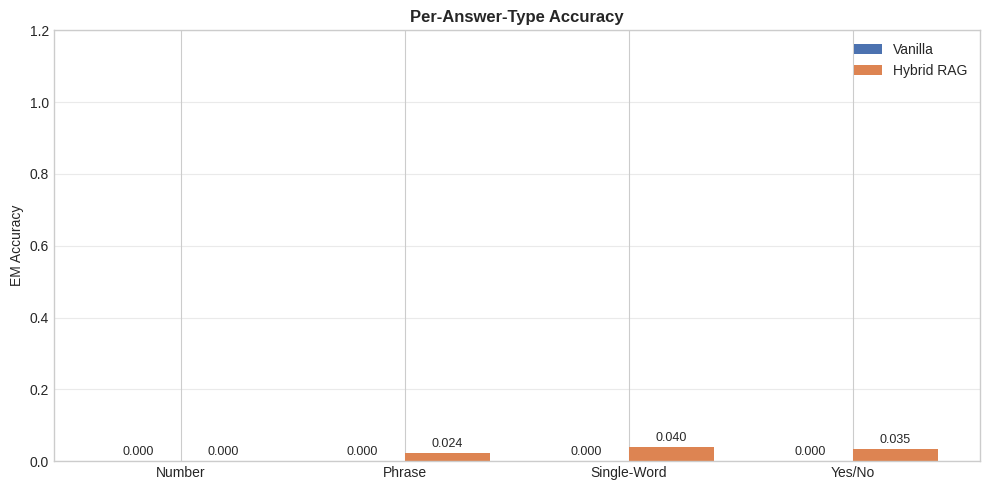

✓ /kaggle/working/figures/fig10_per_type.png


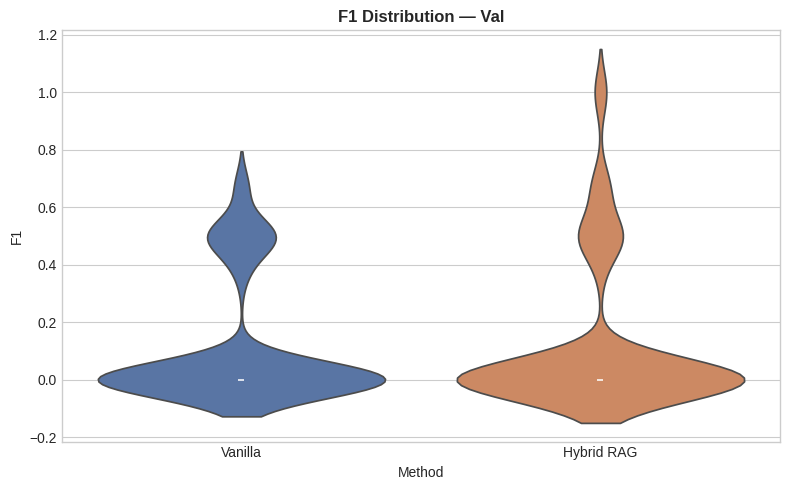

✓ /kaggle/working/figures/fig11_f1_violin.png


In [34]:
# Per-type accuracy
vt=van_df_val.groupby("answer_type")["em"].mean()
ht=hyb_df_val.groupby("answer_type")["em"].mean()
types=sorted(set(vt.index)|set(ht.index))
x=np.arange(len(types)); w=0.38
fig,ax=plt.subplots(figsize=(10,5))
b1=ax.bar(x-w/2,[vt.get(t,0) for t in types],w,label="Vanilla",   color="#4C72B0")
b2=ax.bar(x+w/2,[ht.get(t,0) for t in types],w,label="Hybrid RAG",color="#DD8452")
ax.bar_label(b1,fmt="%.3f",fontsize=9,padding=2)
ax.bar_label(b2,fmt="%.3f",fontsize=9,padding=2)
ax.set_xticks(x); ax.set_xticklabels(types)
ax.set_ylabel("EM Accuracy"); ax.set_ylim(0,1.2)
ax.set_title("Per-Answer-Type Accuracy",fontsize=12,fontweight="bold")
ax.legend(); ax.grid(axis="y",alpha=0.4)
plt.tight_layout()
fp=os.path.join(FDIR,"fig10_per_type.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")

# F1 violin
dp=pd.DataFrame({
    "F1":pd.concat([van_df_val["f1"],hyb_df_val["f1"]],ignore_index=True),
    "Method":["Vanilla"]*len(van_df_val)+["Hybrid RAG"]*len(hyb_df_val),
})
fig,ax=plt.subplots(figsize=(8,5))
sns.violinplot(data=dp,x="Method",y="F1",
               palette=["#4C72B0","#DD8452"],ax=ax,inner="box")
ax.set_title("F1 Distribution — Val",fontsize=12,fontweight="bold")
plt.tight_layout()
fp=os.path.join(FDIR,"fig11_f1_violin.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


## 21. Pipeline Visualisation (FIX: Composite Font)

**FIX**: The previous version used `NotoSansBengali` for all PIL text.
That font has no Latin glyphs → `"RRF: 0.0164"` renders blank.
Solution: Bangla lines use `BN_FONT_SM`, Latin/digit lines use `_LAT_FONT_SM`,
drawn to clearly separated blocks.


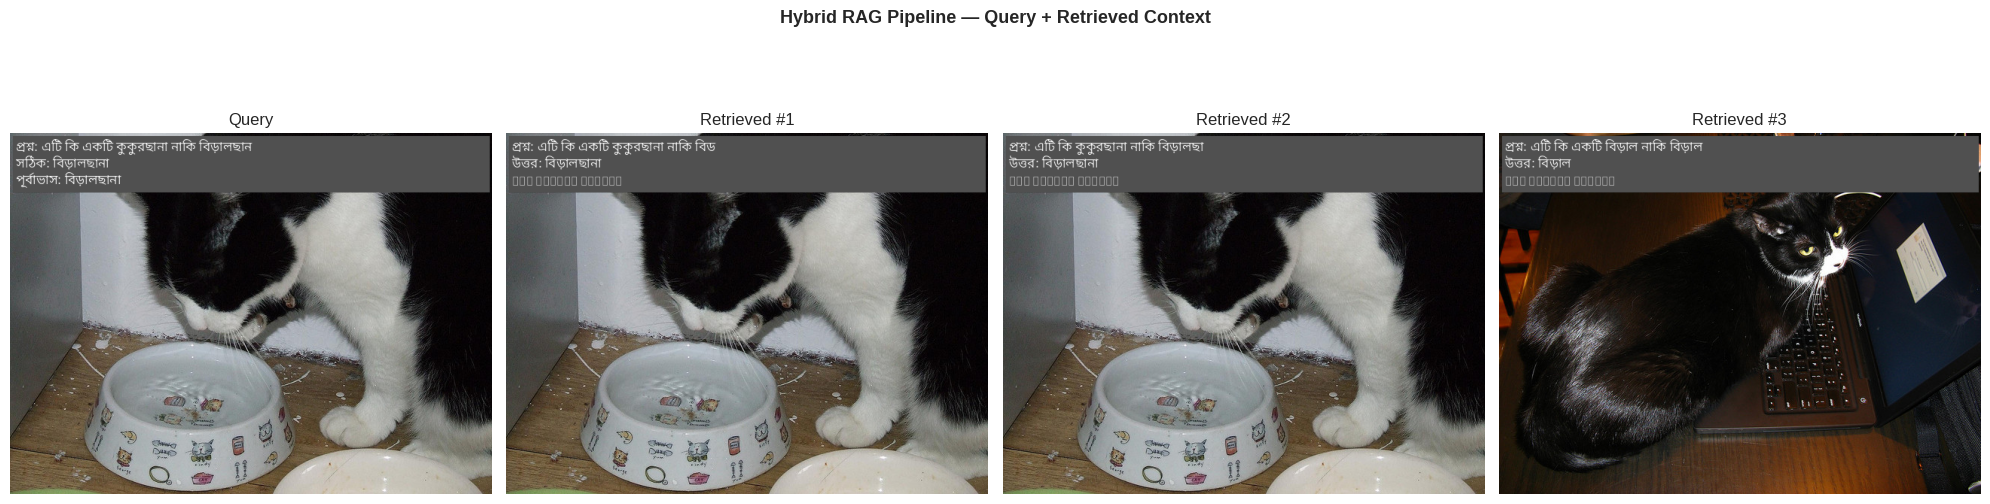

✓ /kaggle/working/figures/fig12_pipeline.png


In [35]:
def visualize_pipeline(sample_idx: int, k: int=3, fname="fig12_pipeline.png"):
    img,q,gt=full_dataset[sample_idx]
    pred,ret=infer_hybrid_rag(img,q); ret=ret[:k]
    fig,axes=plt.subplots(1,k+1,figsize=(5*(k+1),6))

    # Query panel — all Bangla text
    axes[0].imshow(annotate_image(img,
        [f"প্রশ্ন: {q[:36]}",f"সঠিক: {gt}",f"পূর্বাভাস: {pred}"]))
    axes[0].set_title("Query",fontsize=12); axes[0].axis("off")

    for i,item in enumerate(ret):
        rp=os.path.join(full_dataset.images_dir,item["image_file"])
        ri=Image.open(rp).convert("RGB")
        # FIX: Bangla lines + separate Latin line for score
        axes[i+1].imshow(annotate_image(
            ri,
            bn_lines =[f"প্রশ্ন: {item['question'][:30]}",
                       f"উত্তর: {item['answer']}"],
            lat_lines =[f"RRF Score: {item['rrf_score']:.4f}"],
        ))
        axes[i+1].set_title(f"Retrieved #{i+1}",fontsize=12)
        axes[i+1].axis("off")

    plt.suptitle("Hybrid RAG Pipeline — Query + Retrieved Context",
                 fontsize=13,fontweight="bold")
    plt.tight_layout()
    fp=os.path.join(FDIR,fname)
    plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")

visualize_pipeline(sample_idx=20, k=3)


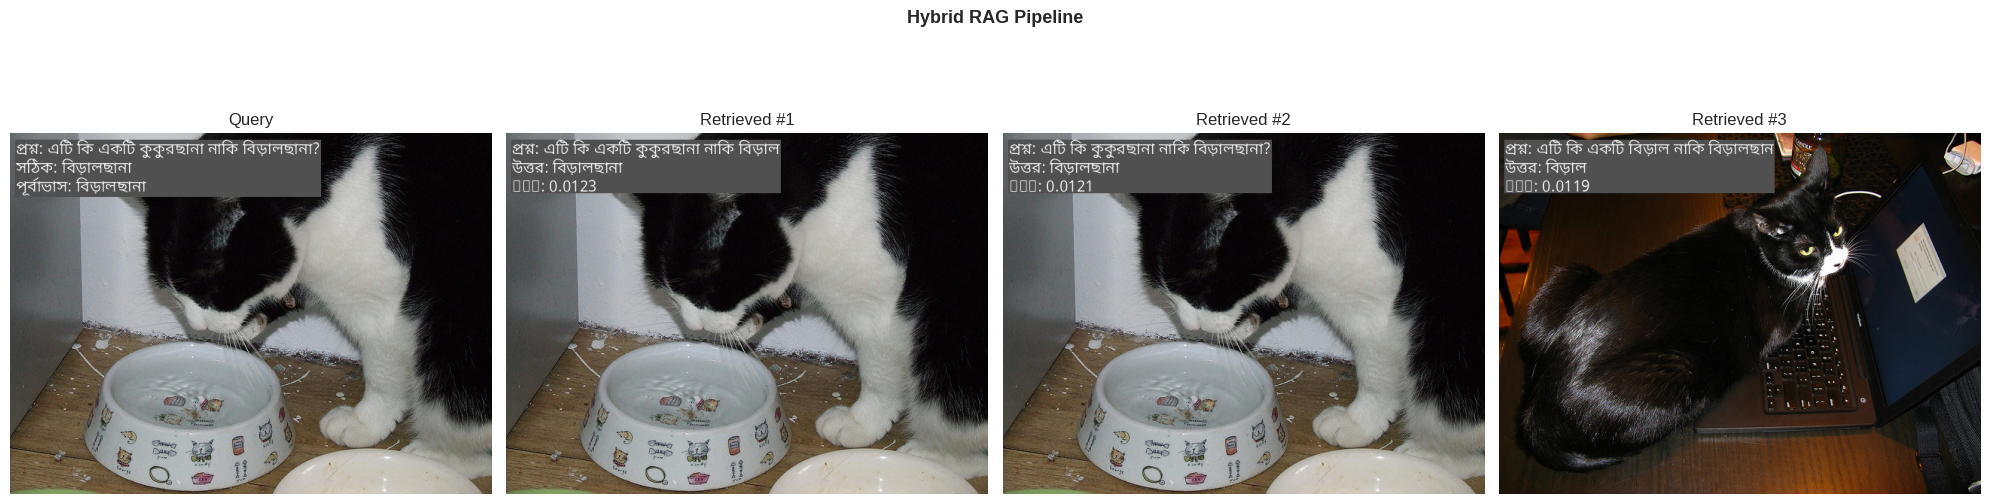

✓ /kaggle/working/figures/fig100_pipeline.png


In [41]:
def visualize_pipeline(sample_idx: int, k: int = 3,
                        fname: str = "fig100_pipeline.png"):
    img, q, gt = full_dataset[sample_idx]
    pred, ret  = infer_hybrid_rag(img, q)
    ret = ret[:k]

    fig, axes = plt.subplots(1, k+1, figsize=(5*(k+1), 6))

    def _ann(base, lines, fnt=BN_FONT_MD):
        im = base.copy().convert("RGBA")
        d  = ImageDraw.Draw(im,"RGBA")
        txt= "\n".join(lines)
        bb = d.multiline_textbbox((8,8),txt,font=fnt)
        d.rectangle(bb,fill=(0,0,0,175))
        d.multiline_text((8,8),txt,font=fnt,fill="white")
        return im

    axes[0].imshow(_ann(img,[f"প্রশ্ন: {q[:38]}",
                              f"সঠিক: {gt}",f"পূর্বাভাস: {pred}"]))
    axes[0].set_title("Query",fontsize=12); axes[0].axis("off")

    for i,item in enumerate(ret):
        rp = os.path.join(full_dataset.images_dir, item["image_file"])
        ri = Image.open(rp).convert("RGB")
        axes[i+1].imshow(_ann(ri,[f"প্রশ্ন: {item['question'][:33]}",
                                   f"উত্তর: {item['answer']}",
                                   f"RRF: {item['rrf_score']:.4f}"]))
        axes[i+1].set_title(f"Retrieved #{i+1}",fontsize=12)
        axes[i+1].axis("off")

    plt.suptitle("Hybrid RAG Pipeline",fontsize=13,fontweight="bold")
    plt.tight_layout()
    fp = os.path.join(FDIR, fname)
    plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show()
    print(f"✓ {fp}")

visualize_pipeline(sample_idx=20, k=3)

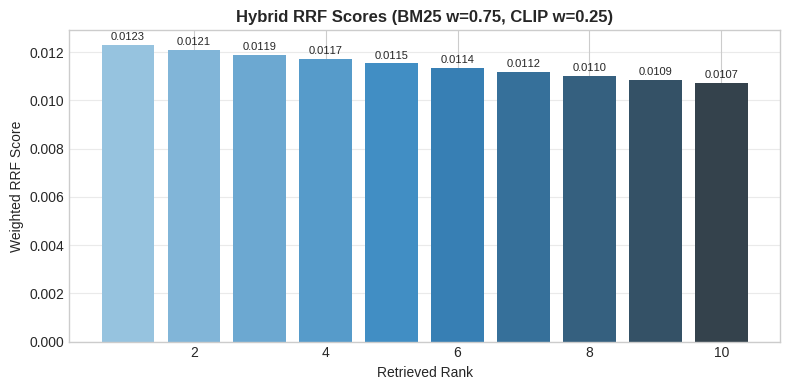

✓ /kaggle/working/figures/fig13_rrf_scores.png


In [36]:
def plot_rrf_scores(sample_idx: int, k: int=10, fname="fig13_rrf_scores.png"):
    img,q,_=full_dataset[sample_idx]
    res=hybrid_retrieve(img,q,top_k=k)
    sc=[r["rrf_score"] for r in res]
    fig,ax=plt.subplots(figsize=(8,4))
    bars=ax.bar(range(1,k+1),sc,color=sns.color_palette("Blues_d",k))
    ax.bar_label(bars,fmt="%.4f",fontsize=8,padding=2)
    ax.set_xlabel("Retrieved Rank"); ax.set_ylabel("Weighted RRF Score")
    ax.set_title("Hybrid RRF Scores (BM25 w=0.75, CLIP w=0.25)",
                 fontsize=12,fontweight="bold")
    ax.grid(axis="y",alpha=0.4)
    plt.tight_layout()
    fp=os.path.join(FDIR,fname)
    plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")

plot_rrf_scores(sample_idx=20)


## 22. Final Summary Figures

In [37]:
all_rows=[{"Metric":m,
           "Vanilla (Val)":van_metrics_val.get(m,np.nan),
           "Hybrid (Val)" :hyb_metrics_val.get(m,np.nan),
           "Hybrid (Test)":hyb_metrics_test.get(m,np.nan)} for m in CMP]
results_df=pd.DataFrame(all_rows).round(4)
print(results_df.to_string(index=False))
results_df.to_csv(os.path.join(FDIR,"final_results_table.csv"),index=False)
print("✓ Saved")


            Metric  Vanilla (Val)  Hybrid (Val)  Hybrid (Test)
  Exact Match (EM)         0.0000        0.0320         0.0220
        Soft Match         0.2500        0.2340         0.2220
          Token F1         0.1231        0.1271         0.1134
            BLEU-1         0.0842        0.0979         0.0861
            BLEU-4         0.0278        0.0274         0.0265
           ROUGE-L         0.1231        0.1271         0.1134
            METEOR         0.0997        0.0908         0.0870
 Context Relevance         0.0000        0.6659         0.6561
      Faithfulness         0.0000        0.2527         0.2283
  Answer Relevance         0.0254        0.0331         0.0331
Hallucination Rate         1.0000        0.7473         0.7717
               MRR         0.0000        0.4366         0.4513
               P@1         0.0000        0.3420         0.3740
               P@3         0.0000        0.2780         0.2933
               P@5         0.0000        0.2592        

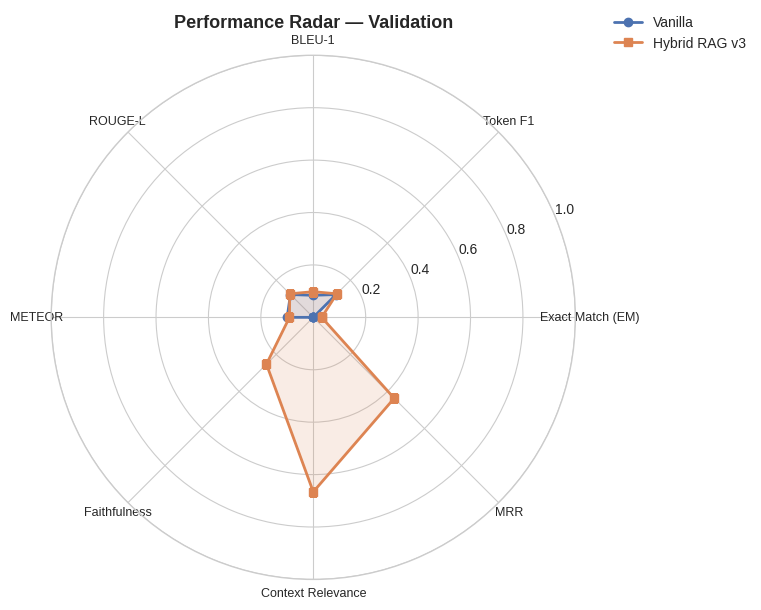

✓ /kaggle/working/figures/fig14_radar.png


In [38]:
# Radar
rm=["Exact Match (EM)","Token F1","BLEU-1","ROUGE-L",
    "METEOR","Faithfulness","Context Relevance","MRR"]
angles=np.linspace(0,2*np.pi,len(rm),endpoint=False).tolist()+[0]
vv=[van_metrics_val.get(m,0) for m in rm]+[van_metrics_val.get(rm[0],0)]
hv=[hyb_metrics_val.get(m,0) for m in rm]+[hyb_metrics_val.get(rm[0],0)]
fig,ax=plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
ax.plot(angles,vv,"o-",lw=2,color="#4C72B0",label="Vanilla")
ax.fill(angles,vv,alpha=0.15,color="#4C72B0")
ax.plot(angles,hv,"s-",lw=2,color="#DD8452",label="Hybrid RAG v3")
ax.fill(angles,hv,alpha=0.15,color="#DD8452")
ax.set_xticks(angles[:-1]); ax.set_xticklabels(rm,fontsize=9)
ax.set_ylim(0,1)
ax.set_title("Performance Radar — Validation",fontsize=13,fontweight="bold",pad=20)
ax.legend(loc="upper right",bbox_to_anchor=(1.35,1.1))
plt.tight_layout()
fp=os.path.join(FDIR,"fig14_radar.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


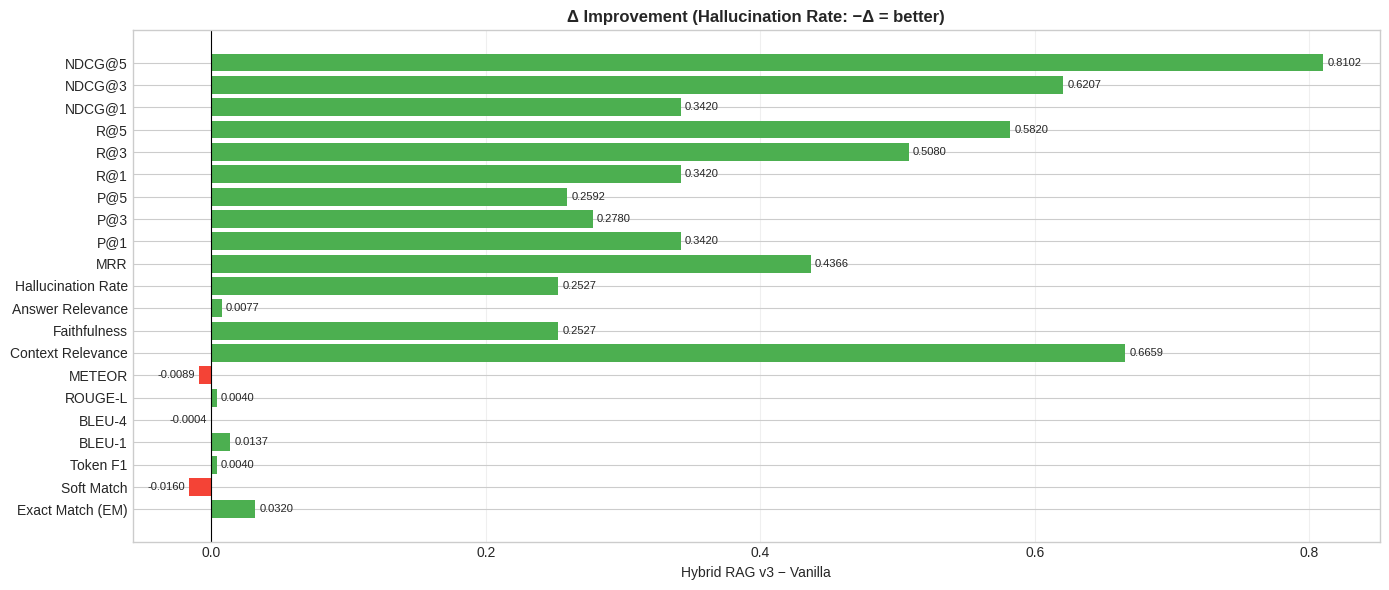

✓ /kaggle/working/figures/fig15_delta.png


In [39]:
# Delta improvement
dd=comp_df.dropna(subset=["Vanilla","Hybrid RAG"]).copy()
dd["Δ"]=dd["Hybrid RAG"]-dd["Vanilla"]
dd.loc[dd["Metric"]=="Hallucination Rate","Δ"]*=-1
cl=["#4CAF50" if v>=0 else "#F44336" for v in dd["Δ"]]
fig,ax=plt.subplots(figsize=(14,6))
bars=ax.barh(dd["Metric"],dd["Δ"],color=cl)
ax.bar_label(bars,fmt="%.4f",fontsize=8,padding=3)
ax.axvline(0,color="black",lw=0.8)
ax.set_xlabel("Hybrid RAG v3 − Vanilla"); ax.grid(axis="x",alpha=0.3)
ax.set_title("Δ Improvement (Hallucination Rate: −Δ = better)",
             fontsize=12,fontweight="bold")
plt.tight_layout()
fp=os.path.join(FDIR,"fig15_delta.png")
plt.savefig(fp,dpi=DPI,bbox_inches="tight"); plt.show(); print(f"✓ {fp}")


## 23. All Outputs & Classification Report

In [40]:
import glob
saved=sorted(glob.glob(os.path.join(FDIR,"*.png")))
print(f"{'─'*62}\n  {len(saved)} figures @ DPI={DPI} → {FDIR}\n{'─'*62}")
for p in saved:
    print(f"  {os.path.basename(p):50s}  {os.path.getsize(p)/1024:7.1f} KB")

print("\n── Classification Report (Hybrid RAG v3, Test Set) ──")
print(classification_report(hyb_test["y_true"],hyb_test["y_pred"],
                             labels=hyb_test["labels"][:20],zero_division=0))

print("\n── MCCV Final Summary ──")
for row in mccv_summary.loc[["em","f1","rougeL","mrr"]].itertuples():
    print(f"  {row.Index:10s}  Mean={row.Mean:.4f} ± {row.Std:.4f}  "
          f"95%CI±{row._3:.4f}  [{row.Min:.4f},{row.Max:.4f}]")

print("\n── Research Title ──")
print('  "HybridRAG-BanglaVQA: A Weighted Dense-Sparse Retrieval-Augmented')
print('   Generation Framework for Low-Resource Multimodal Bengali Visual')
print('   Question Answering"')


──────────────────────────────────────────────────────────────
  18 figures @ DPI=450 → /kaggle/working/figures
──────────────────────────────────────────────────────────────
  fig01_eda_bn.png                                      442.3 KB
  fig01_eda_overview.png                                422.9 KB
  fig03_splits.png                                      237.7 KB
  fig04_cm_vanilla.png                                  265.4 KB
  fig05_cm_hybrid_val.png                               276.5 KB
  fig06_cm_hybrid_test.png                              272.4 KB
  fig07_core_metrics.png                                284.5 KB
  fig08_retrieval_metrics.png                           149.9 KB
  fig09_rag_quality.png                                 250.1 KB
  fig10_per_type.png                                    147.5 KB
  fig11_f1_violin.png                                   196.1 KB
  fig12_pipeline.png                                   1605.6 KB
  fig13_rrf_scores.png                       